### Statistics

Total Sequences: 6585
Mean Length: 54.30
Median Length: 30.0
Standard Deviation: 65.97
Min Length: 6
Max Length: 249


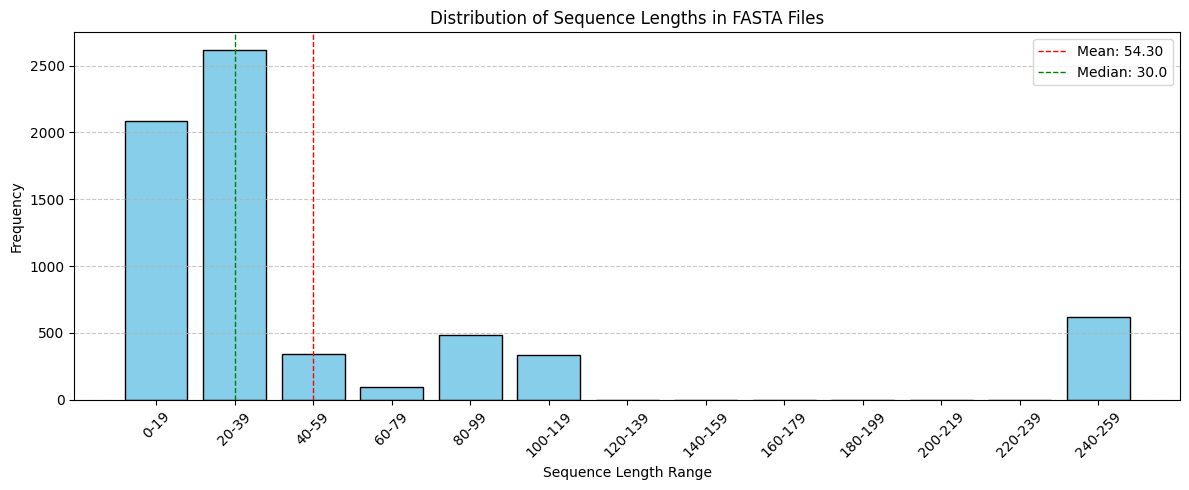

In [ ]:
import os
import glob
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

def parse_fasta_lengths(file_path):
    lengths = []
    with open(file_path, 'r') as file:
        sequence = ""
        for line in file:
            if line.startswith(">"):
                if sequence:
                    lengths.append(len(sequence))
                    sequence = ""
            else:
                sequence += line.strip()
        if sequence:
            lengths.append(len(sequence))   
    return lengths

 
directories = ["data\AMP", "data\HIV"]

# Extract lengths from all FASTA files in both directories
all_lengths = []
for directory in directories:
    fasta_files = glob.glob(os.path.join(directory, "*.fasta"))   
    for fasta_file in fasta_files:
        all_lengths.extend(parse_fasta_lengths(fasta_file))

# Compute statistics
mean_length = np.mean(all_lengths)
median_length = np.median(all_lengths)
std_dev_length = np.std(all_lengths)
min_length = min(all_lengths)
max_length = max(all_lengths)

# Print statistics
print(f"Total Sequences: {len(all_lengths)}")
print(f"Mean Length: {mean_length:.2f}")
print(f"Median Length: {median_length}")
print(f"Standard Deviation: {std_dev_length:.2f}")
print(f"Min Length: {min_length}")
print(f"Max Length: {max_length}")

# Count occurrences of each length
length_counts = Counter(all_lengths)

# Group sequence lengths into ranges
bins = range(0, max_length + 20, 20)   
binned_lengths = np.digitize(all_lengths, bins)

# Count occurrences in each bin
binned_counts = Counter(binned_lengths)

# Prepare data for plotting
bin_labels = [f"{bins[i]}-{bins[i+1]-1}" for i in range(len(bins)-1)]
bin_values = [binned_counts[i+1] for i in range(len(bin_labels))]

# Plot histogram
plt.figure(figsize=(12, 5))
plt.bar(bin_labels, bin_values, color='skyblue', edgecolor='black')
plt.xlabel('Sequence Length Range')
plt.ylabel('Frequency')
plt.title('Distribution of Sequence Lengths in FASTA Files')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axvline(mean_length // 20, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean_length:.2f}')
plt.axvline(median_length // 20, color='green', linestyle='dashed', linewidth=1, label=f'Median: {median_length}')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


### To be added to the paper

### Comparison of FNN vs CNN trained on data with sf 0.5

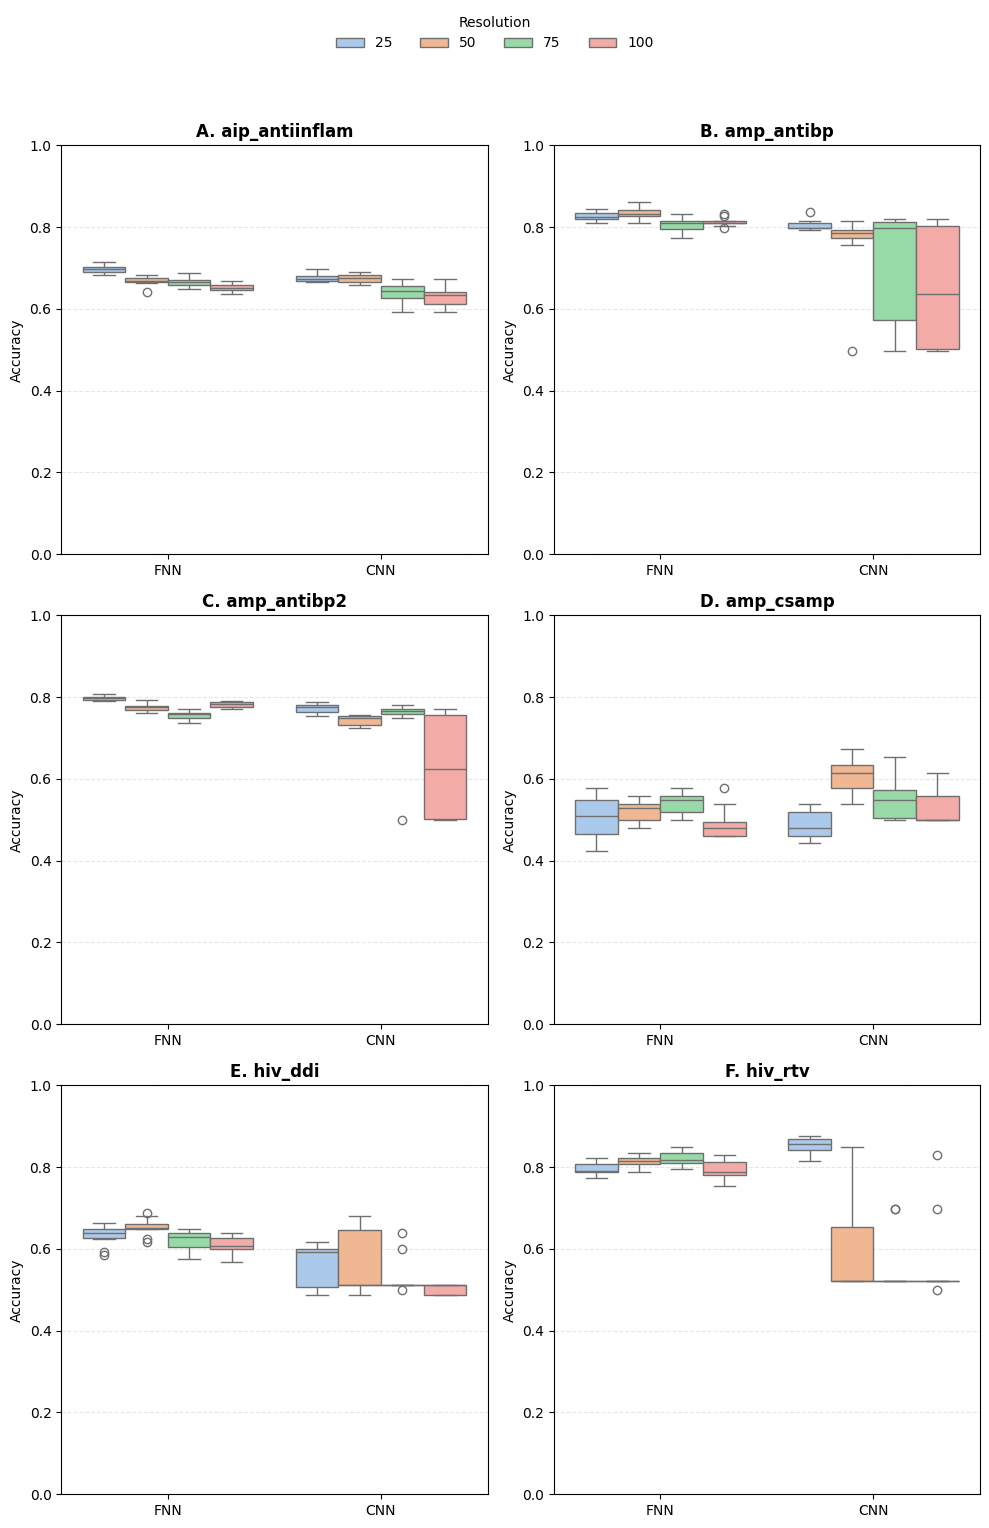

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
file_paths = ["reports/classification_results2_FNN.json", "reports/classification_results3_CNN.json"]

data = []

# Read and process each file
for file_path in file_paths:
    with open(file_path, "r") as f:
        results = json.load(f)

    # Extract model name from file name
    model_name = file_path.split("_")[-1].split(".")[0][-3:]    

    for entry in results:
        dataset_name = "_".join(entry["dataset"].split("_")[:-1])
        resolution = entry["dataset"].split("_")[-1]

        for acc in entry["accuracies"]:
            data.append({
                "Dataset": dataset_name,
                "Model": model_name,
                "Resolution": resolution,
                "Score": acc
            })

# Create DataFrame
df = pd.DataFrame(data)

df = df[df["Dataset"] != "hiv_lpv"]    # Exclude 'hiv_lpv' since some files still have it

# Get unique datasets
datasets = df["Dataset"].unique()

# Create a grid of subplots (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(10, 15))    
axes = axes.flatten()    

  
labels = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
resolution_order = ["25", "50", "75", "100"]
# Plot each dataset in a separate subplot
for i, dataset in enumerate(datasets):
    if i < len(axes):    
        sns.boxplot(
            x="Model", y="Score", hue="Resolution", hue_order=resolution_order,
            data=df[df["Dataset"] == dataset], palette="pastel", ax=axes[i]
        )
        axes[i].set_title(f"{labels[i]}. {dataset}", fontsize=12, fontweight="bold")
        axes[i].set_ylabel("Accuracy", fontsize=10)
        axes[i].set_xlabel("")
        axes[i].legend(title="Resolution", fontsize=8)
        axes[i].grid(alpha=0.3, linestyle="--", axis="y")
        axes[i].set_ylim(0.0, 1.0)
        axes[i].legend_.remove()      

  
for j in range(len(datasets), len(axes)):
    fig.delaxes(axes[j])

  
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, legend_labels,
    title="Resolution",
    loc="upper center",
    ncol=len(legend_labels),
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("boxplot/FNNvsCNN/FNN_vs_CNN_acc.pdf", bbox_inches='tight')
plt.show()

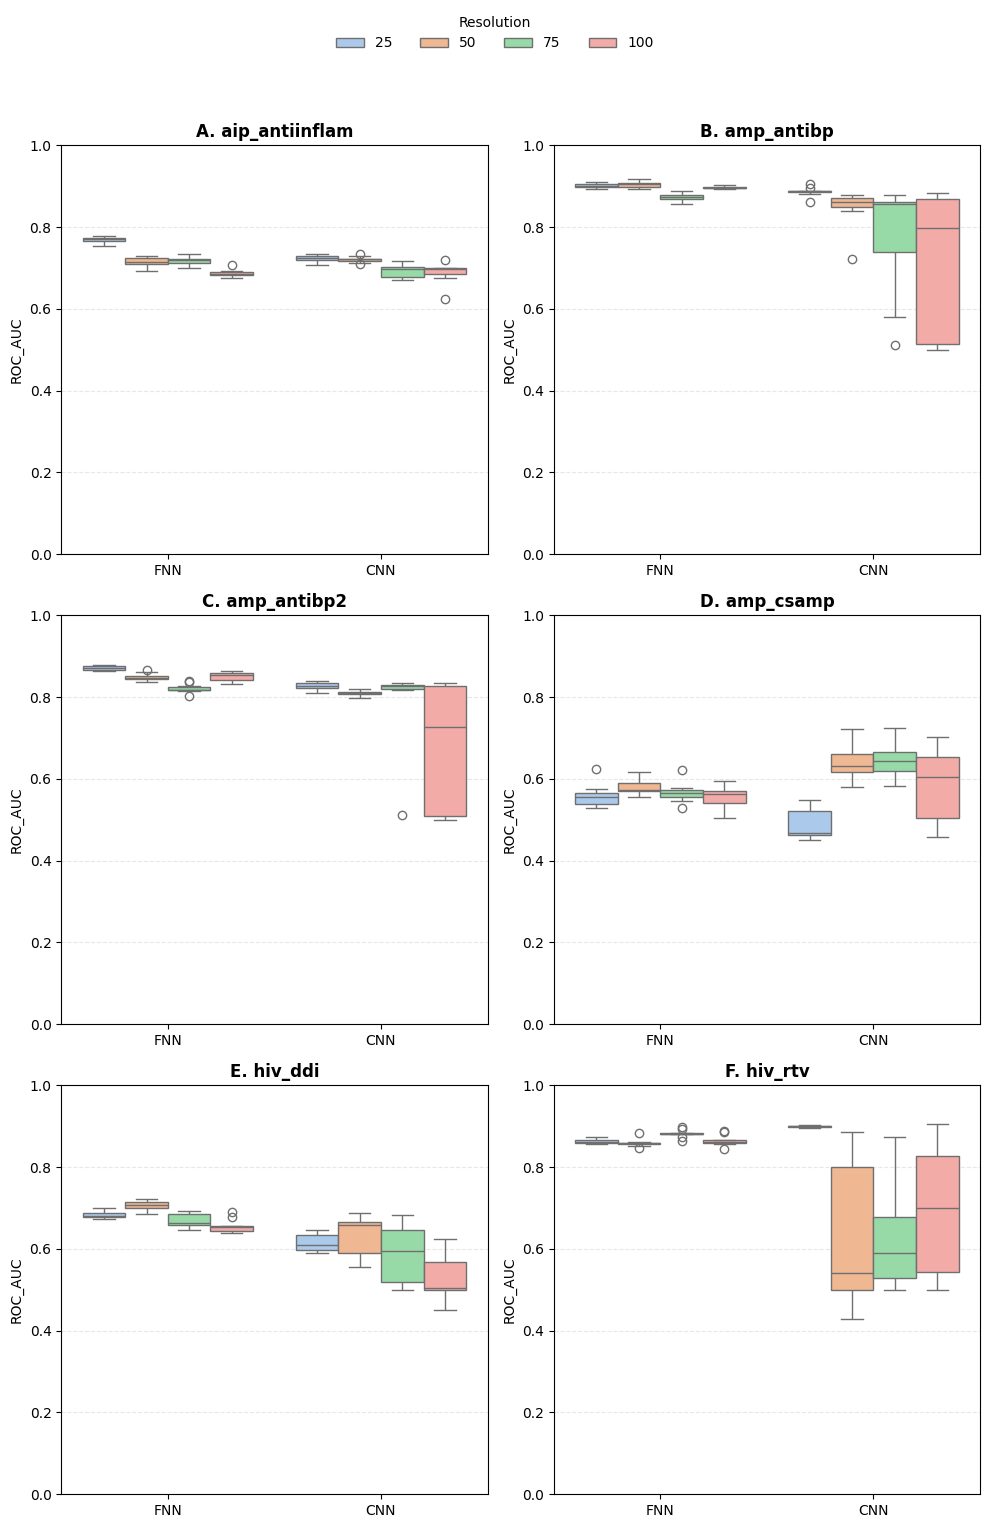

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
file_paths = ["reports/classification_results2_FNN.json", "reports/classification_results3_CNN.json"]

data = []

# Read and process each file
for file_path in file_paths:
    with open(file_path, "r") as f:
        results = json.load(f)

    # Extract model name from file name
    model_name = file_path.split("_")[-1].split(".")[0][-3:]    

    for entry in results:
        dataset_name = "_".join(entry["dataset"].split("_")[:-1])
        resolution = entry["dataset"].split("_")[-1]

        for auc in entry["roc_aucs"]:
            data.append({
                "Dataset": dataset_name,
                "Model": model_name,
                "Resolution": resolution,
                "Score": auc
            })

# Create DataFrame
df = pd.DataFrame(data)

df = df[df["Dataset"] != "hiv_lpv"]    # Exclude 'hiv_lpv' since some files still have it

# Get unique datasets
datasets = df["Dataset"].unique()

# Create a grid of subplots (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(10, 15))    
axes = axes.flatten()    

  
labels = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
resolution_order = ["25", "50", "75", "100"]
# Plot each dataset in a separate subplot
for i, dataset in enumerate(datasets):
    if i < len(axes):    
        sns.boxplot(
            x="Model", y="Score", hue="Resolution", hue_order=resolution_order,
            data=df[df["Dataset"] == dataset], palette="pastel", ax=axes[i]
        )
        axes[i].set_title(f"{labels[i]}. {dataset}", fontsize=12, fontweight="bold")
        axes[i].set_ylabel("ROC_AUC", fontsize=10)
        axes[i].set_xlabel("")
        axes[i].legend(title="Resolution", fontsize=8)
        axes[i].grid(alpha=0.3, linestyle="--", axis="y")
        axes[i].set_ylim(0.0, 1.0)
        axes[i].legend_.remove()      

  
for j in range(len(datasets), len(axes)):
    fig.delaxes(axes[j])

  
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, legend_labels,
    title="Resolution",
    loc="upper center",
    ncol=len(legend_labels),
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("boxplot/FNNvsCNN/FNN_vs_CNN_auc.pdf", bbox_inches='tight')
plt.show()

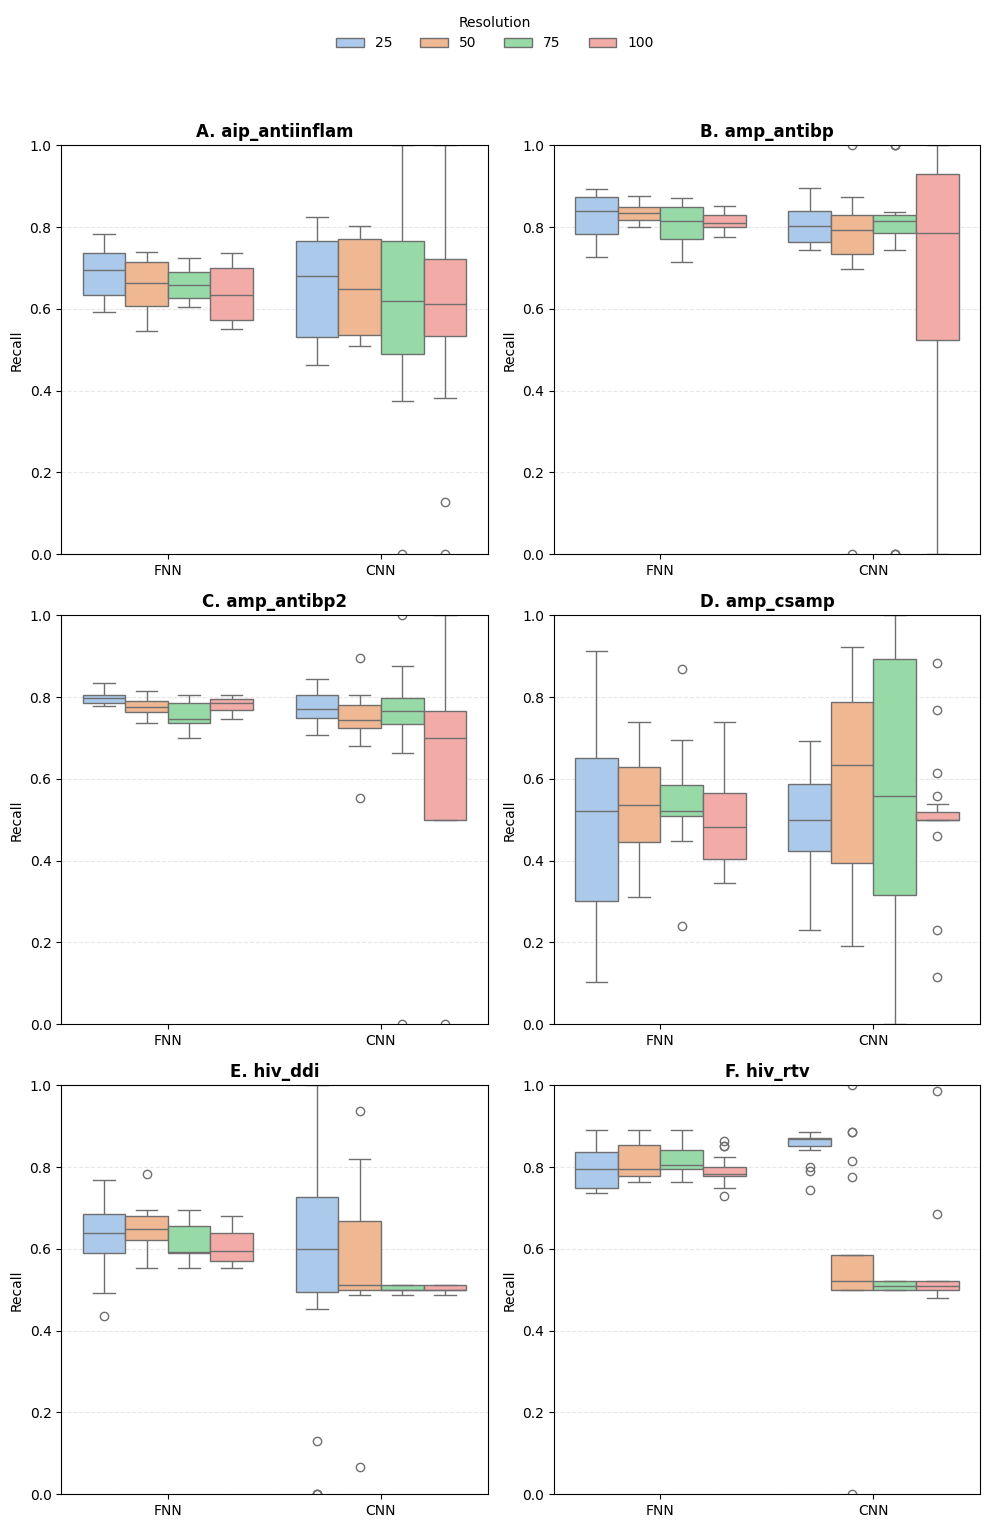

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
file_paths = ["reports/classification_results2_FNN.json", "reports/classification_results3_CNN.json"]

data = []

# Read and process each file
for file_path in file_paths:
    with open(file_path, "r") as f:
        results = json.load(f)

    # Extract model name from file name
    model_name = file_path.split("_")[-1].split(".")[0][-3:]    

    for entry in results:
        dataset_name = "_".join(entry["dataset"].split("_")[:-1])
        resolution = entry["dataset"].split("_")[-1]
        for fold_metric in entry["fold_metrics"]:
            for label, metrics in fold_metric.items():
                data.append({
                    "Dataset": dataset_name,
                    "Model": model_name,
                    "Resolution": resolution,
                    "Class": label,
                    "Score": metrics["recall"]
                })

# Convert to DataFrame
df = pd.DataFrame(data)
df = df[df["Dataset"] != "hiv_lpv"]    # Exclude 'hiv_lpv' since some files still have it

# Get unique datasets
datasets = df["Dataset"].unique()

# Create a grid of subplots (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(10, 15))    
axes = axes.flatten()    

  
labels = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
resolution_order = ["25", "50", "75", "100"]
# Plot each dataset in a separate subplot
for i, dataset in enumerate(datasets):
    if i < len(axes):    
        sns.boxplot(
            x="Model", y="Score", hue="Resolution", hue_order=resolution_order,
            data=df[df["Dataset"] == dataset], palette="pastel", ax=axes[i]
        )
        axes[i].set_title(f"{labels[i]}. {dataset}", fontsize=12, fontweight="bold")
        axes[i].set_ylabel("Recall", fontsize=10)
        axes[i].set_xlabel("")
        axes[i].legend(title="Resolution", fontsize=8)
        axes[i].grid(alpha=0.3, linestyle="--", axis="y")
        axes[i].set_ylim(0.0, 1.0)
        axes[i].set_ylim(0.0, 1.0)
        axes[i].legend_.remove()      

  
for j in range(len(datasets), len(axes)):
    fig.delaxes(axes[j])

  
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, legend_labels,
    title="Resolution",
    loc="upper center",
    ncol=len(legend_labels),
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("boxplot/FNNvsCNN/FNN_vs_CNN_rec.pdf", bbox_inches='tight')
plt.show()

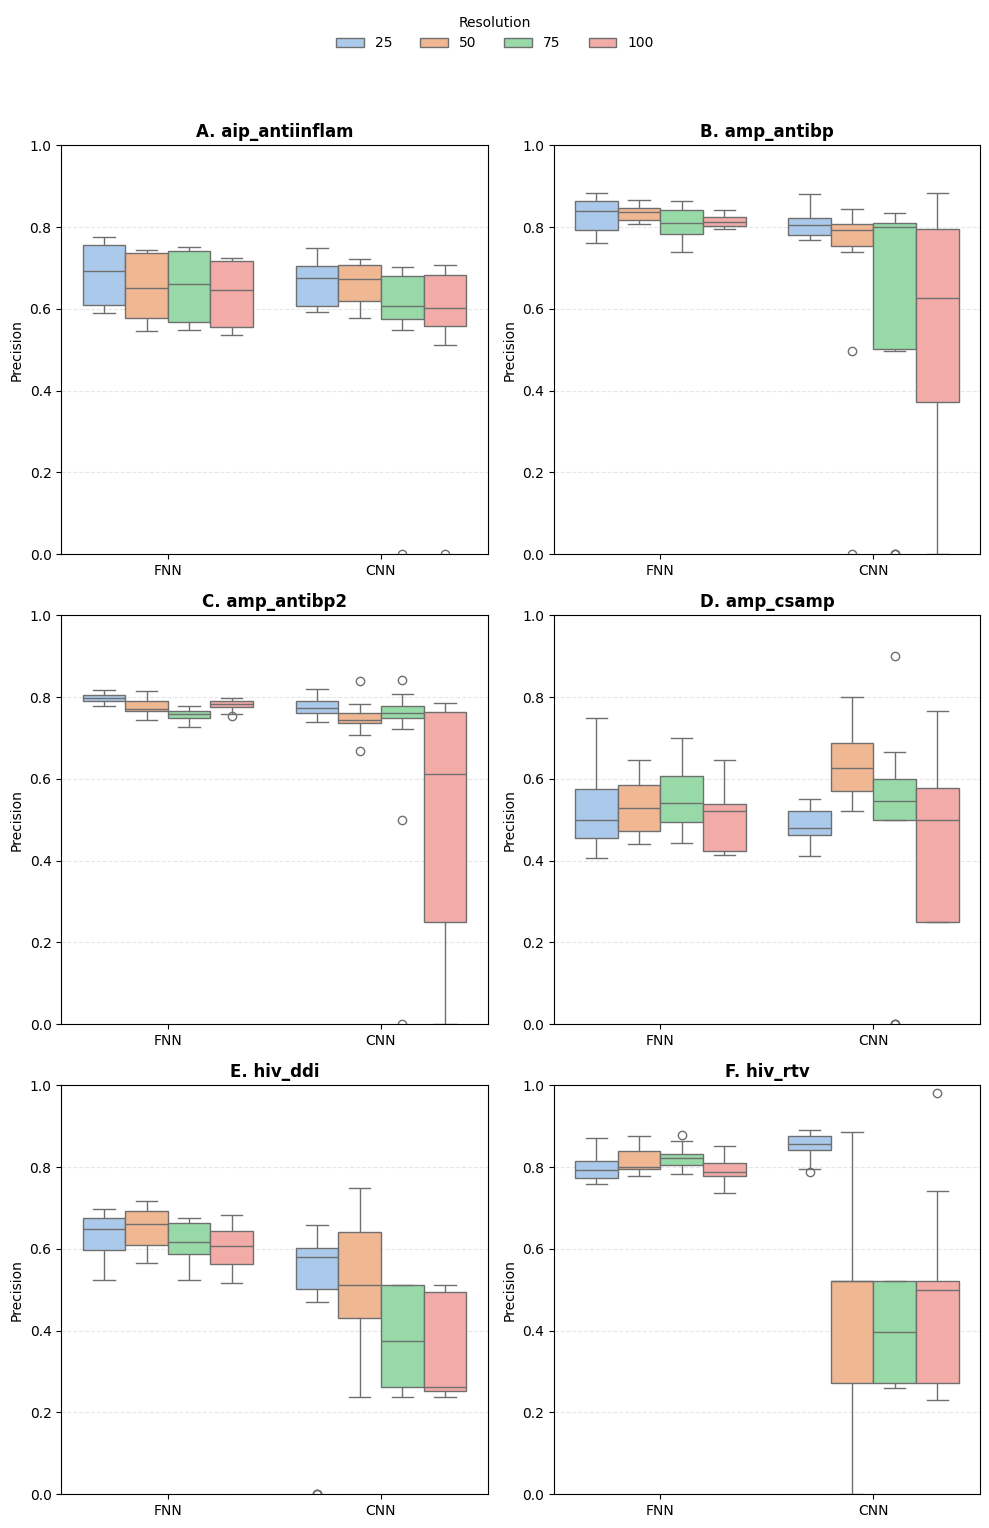

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
file_paths = ["reports/classification_results2_FNN.json", "reports/classification_results3_CNN.json"]

data = []

# Read and process each file
for file_path in file_paths:
    with open(file_path, "r") as f:
        results = json.load(f)

    # Extract model name from file name
    model_name = file_path.split("_")[-1].split(".")[0][-3:]    

    for entry in results:
        dataset_name = "_".join(entry["dataset"].split("_")[:-1])
        resolution = entry["dataset"].split("_")[-1]
        for fold_metric in entry["fold_metrics"]:
            for label, metrics in fold_metric.items():
                data.append({
                    "Dataset": dataset_name,
                    "Model": model_name,
                    "Resolution": resolution,
                    "Class": label,
                    "Score": metrics["precision"]
                })

# Convert to DataFrame
df = pd.DataFrame(data)
df = df[df["Dataset"] != "hiv_lpv"]    # Exclude 'hiv_lpv' since some files still have it

# Get unique datasets
datasets = df["Dataset"].unique()

# Create a grid of subplots (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(10, 15))    
axes = axes.flatten()    

  
labels = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
resolution_order = ["25", "50", "75", "100"]
# Plot each dataset in a separate subplot
for i, dataset in enumerate(datasets):
    if i < len(axes):    
        sns.boxplot(
            x="Model", y="Score", hue="Resolution", hue_order=resolution_order,
            data=df[df["Dataset"] == dataset], palette="pastel", ax=axes[i]
        )
        axes[i].set_title(f"{labels[i]}. {dataset}", fontsize=12, fontweight="bold")
        axes[i].set_ylabel("Precision", fontsize=10)
        axes[i].set_xlabel("")
        axes[i].legend(title="Resolution", fontsize=8)
        axes[i].grid(alpha=0.3, linestyle="--", axis="y")
        axes[i].set_ylim(0.0, 1.0)
        axes[i].set_ylim(0.0, 1.0)
        axes[i].legend_.remove()      

  
for j in range(len(datasets), len(axes)):
    fig.delaxes(axes[j])

  
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, legend_labels,
    title="Resolution",
    loc="upper center",
    ncol=len(legend_labels),
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("boxplot/FNNvsCNN/FNN_vs_CNN_prec.pdf", bbox_inches='tight')
plt.show()

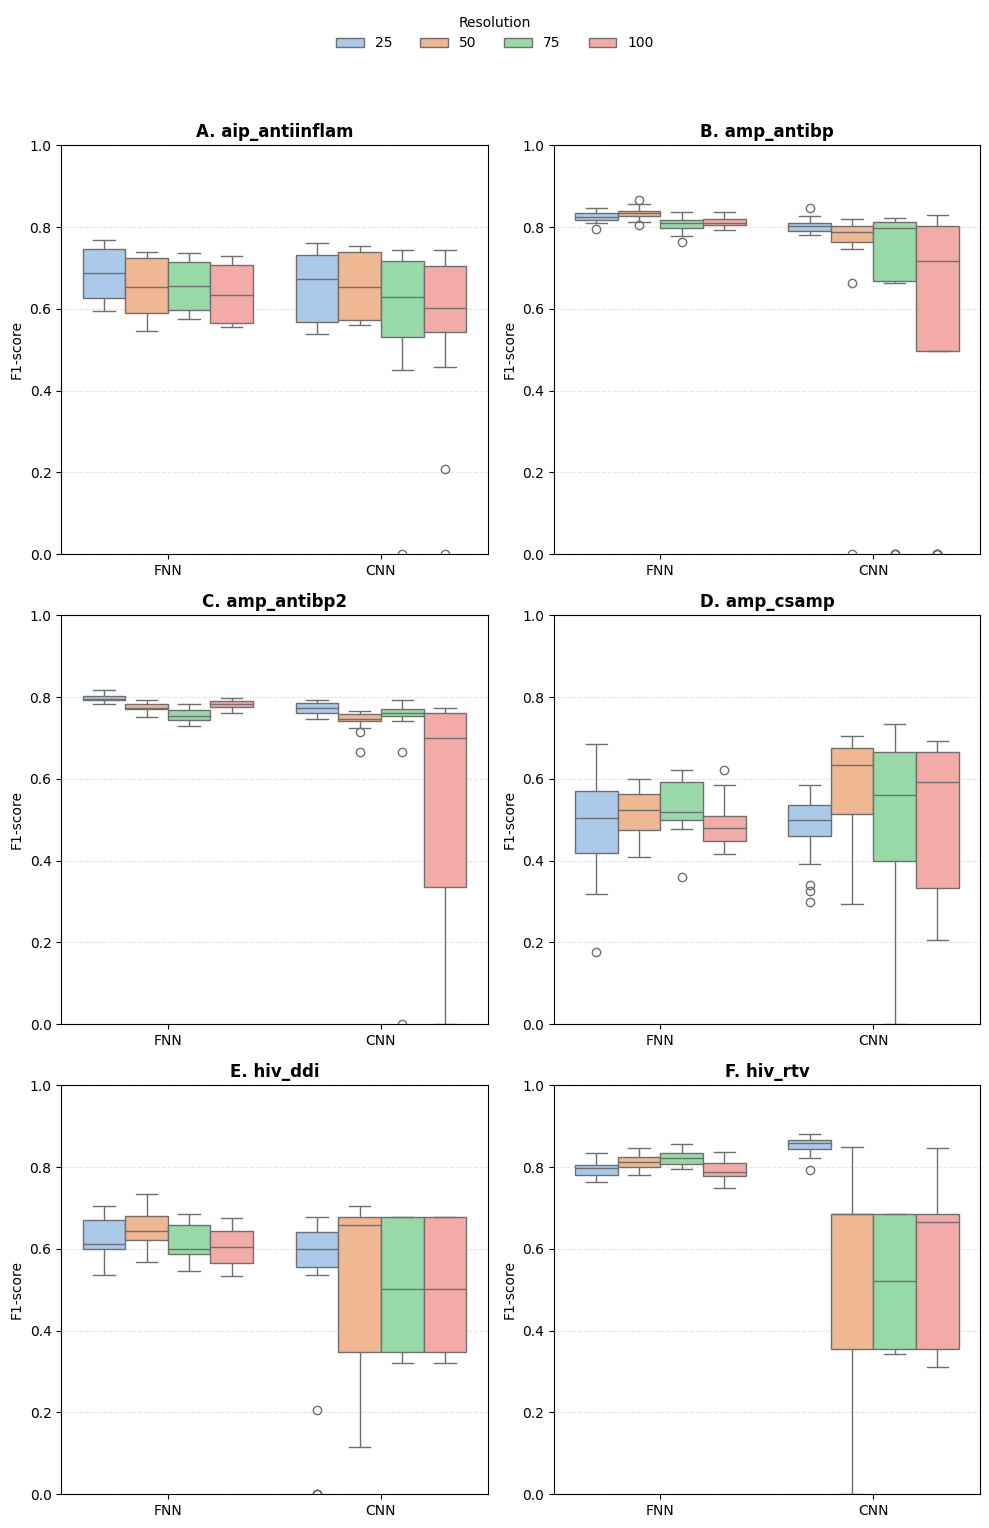

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
file_paths = ["reports/classification_results2_FNN.json", "reports/classification_results3_CNN.json"]

data = []

# Read and process each file
for file_path in file_paths:
    with open(file_path, "r") as f:
        results = json.load(f)

    # Extract model name from file name
    model_name = file_path.split("_")[-1].split(".")[0][-3:]    

    for entry in results:
        dataset_name = "_".join(entry["dataset"].split("_")[:-1])
        resolution = entry["dataset"].split("_")[-1]
        for fold_metric in entry["fold_metrics"]:
            for label, metrics in fold_metric.items():
                data.append({
                    "Dataset": dataset_name,
                    "Model": model_name,
                    "Resolution": resolution,
                    "Class": label,
                    "Score": metrics["f1-score"]
                })

# Convert to DataFrame
df = pd.DataFrame(data)
df = df[df["Dataset"] != "hiv_lpv"]    # Exclude 'hiv_lpv' since some files still have it

# Get unique datasets
datasets = df["Dataset"].unique()

# Create a grid of subplots (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(10, 15))    
axes = axes.flatten()    

  
labels = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
resolution_order = ["25", "50", "75", "100"]
# Plot each dataset in a separate subplot
for i, dataset in enumerate(datasets):
    if i < len(axes):    
        sns.boxplot(
            x="Model", y="Score", hue="Resolution", hue_order=resolution_order,
            data=df[df["Dataset"] == dataset], palette="pastel", ax=axes[i]
        )
        axes[i].set_title(f"{labels[i]}. {dataset}", fontsize=12, fontweight="bold")
        axes[i].set_ylabel("F1-score", fontsize=10)
        axes[i].set_xlabel("")
        axes[i].legend(title="Resolution", fontsize=8)
        axes[i].grid(alpha=0.3, linestyle="--", axis="y")
        axes[i].set_ylim(0.0, 1.0)
        axes[i].legend_.remove()      

  
for j in range(len(datasets), len(axes)):
    fig.delaxes(axes[j])

  
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, legend_labels,
    title="Resolution",
    loc="upper center",
    ncol=len(legend_labels),
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("boxplot/FNNvsCNN/FNN_vs_CNN_f1.pdf", bbox_inches='tight')
plt.show()

### Comparing CNN on sf 0.5 and protein sf 


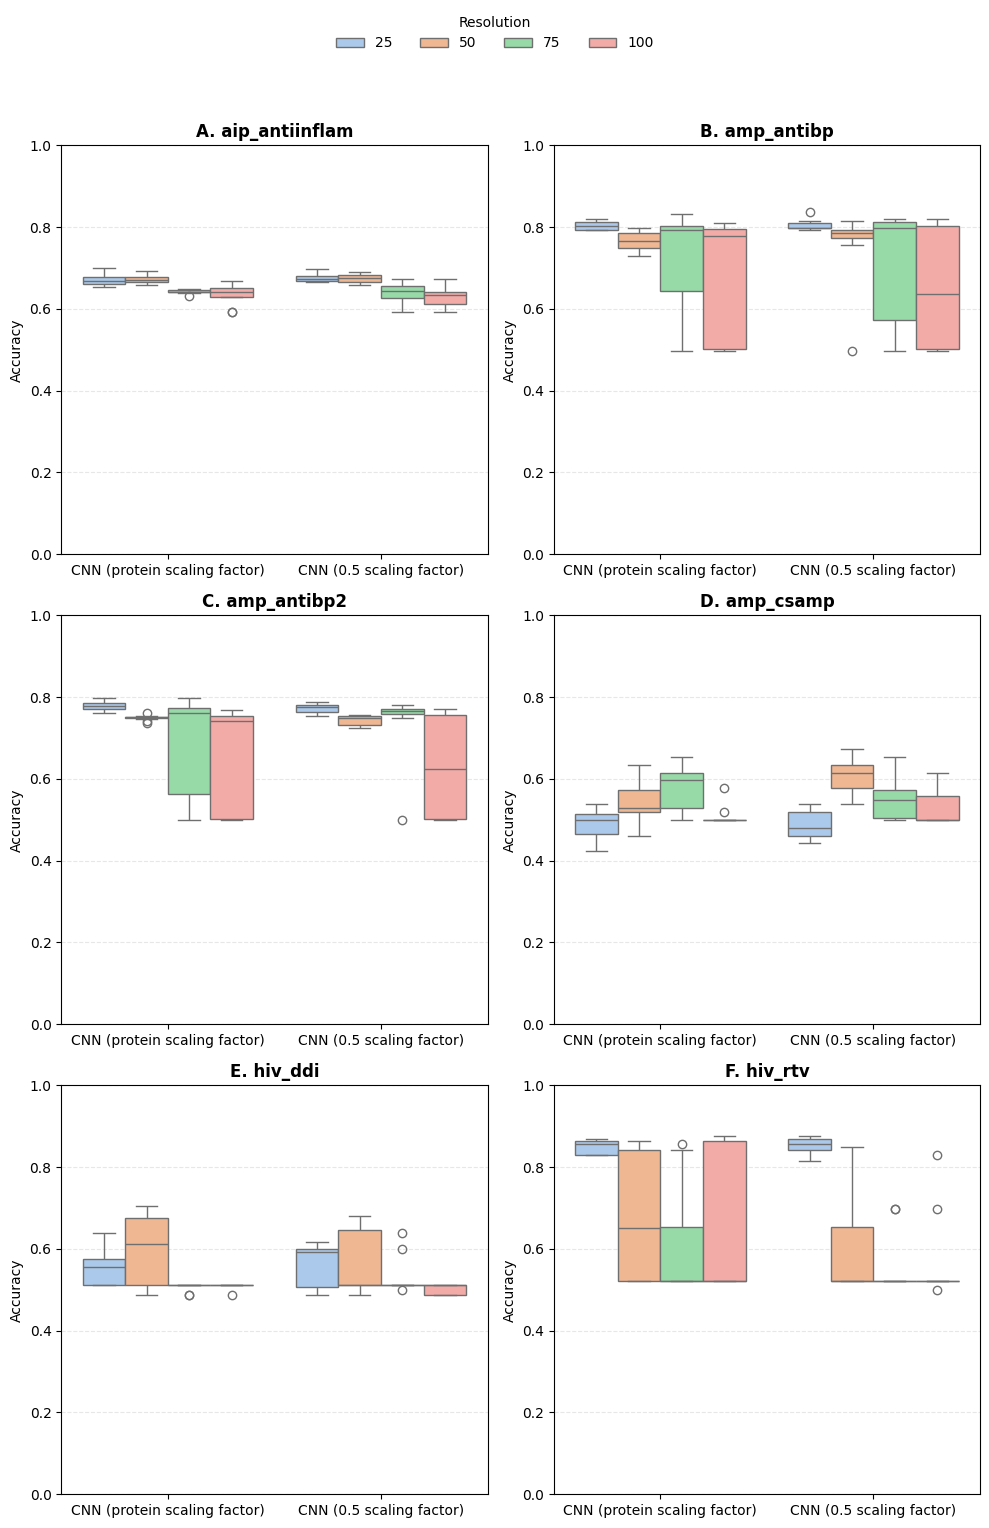

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
file_paths = ["reports/nosf/classification_results3_CNN.json", "reports/classification_results3_CNN.json"]

data = []

# Read and process each file
for file_path in file_paths:
    with open(file_path, "r") as f:
        results = json.load(f)

    # Extract model name from file name
    if "nosf/" in file_path:
        model_name = "CNN (protein scaling factor)"  # Adjusted model name for nosf file path meaning protein scale factor
    else:
        model_name = "CNN (0.5 scaling factor)"  # Adjusted model name for 0.5 sf

    for entry in results:
        dataset_name = "_".join(entry["dataset"].split("_")[:-1])
        resolution = entry["dataset"].split("_")[-1]

        for acc in entry["accuracies"]:
            data.append({
                "Dataset": dataset_name,
                "Model": model_name,
                "Resolution": resolution,
                "Score": acc
            })

# Create DataFrame
df = pd.DataFrame(data)

df = df[df["Dataset"] != "hiv_lpv"]    # Exclude 'hiv_lpv' since some files still have it

# Get unique datasets
datasets = df["Dataset"].unique()

# Create a grid of subplots (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(10, 15))    
axes = axes.flatten()    

  
labels = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
resolution_order = ["25", "50", "75", "100"]
# Plot each dataset in a separate subplot
for i, dataset in enumerate(datasets):
    if i < len(axes):    
        sns.boxplot(
            x="Model", y="Score", hue="Resolution", hue_order=resolution_order,
            data=df[df["Dataset"] == dataset], palette="pastel", ax=axes[i]
        )
        axes[i].set_title(f"{labels[i]}. {dataset}", fontsize=12, fontweight="bold")
        axes[i].set_ylabel("Accuracy", fontsize=10)
        axes[i].set_xlabel("")
        axes[i].legend(title="Resolution", fontsize=8)
        axes[i].grid(alpha=0.3, linestyle="--", axis="y")
        axes[i].set_ylim(0.0, 1.0)
        axes[i].legend_.remove()      

  
for j in range(len(datasets), len(axes)):
    fig.delaxes(axes[j])

  
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, legend_labels,
    title="Resolution",
    loc="upper center",
    ncol=len(legend_labels),
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("boxplot/CNNvsCNNsf/CNN_vs_CNNsf_acc.pdf", bbox_inches='tight')
plt.show()

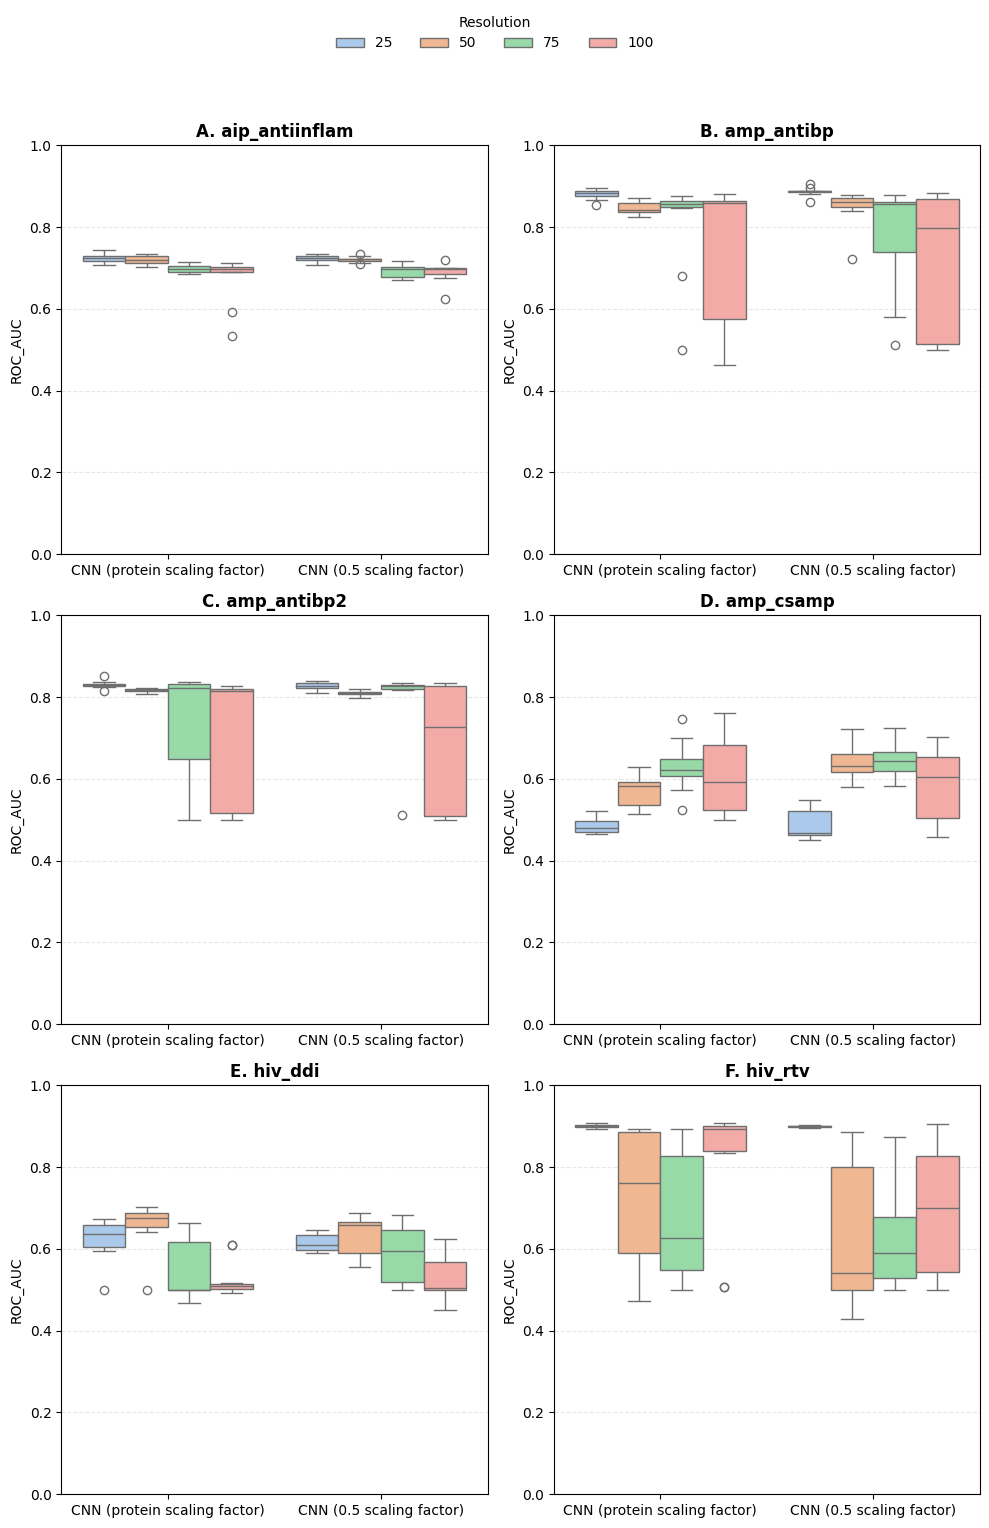

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
# File paths
file_paths = ["reports/nosf/classification_results3_CNN.json", "reports/classification_results3_CNN.json"]

data = []

# Read and process each file
for file_path in file_paths:
    with open(file_path, "r") as f:
        results = json.load(f)

    # Extract model name from file name
    if "nosf/" in file_path:
        model_name = "CNN (protein scaling factor)"  # Adjusted model name for nosf file path meaning protein scale factor
    else:
        model_name = "CNN (0.5 scaling factor)"  # Adjusted model name for 0.5 sf

    for entry in results:
        dataset_name = "_".join(entry["dataset"].split("_")[:-1])
        resolution = entry["dataset"].split("_")[-1]

        for auc in entry["roc_aucs"]:
            data.append({
                "Dataset": dataset_name,
                "Model": model_name,
                "Resolution": resolution,
                "Score": auc
            })

# Create DataFrame
df = pd.DataFrame(data)

df = df[df["Dataset"] != "hiv_lpv"]    # Exclude 'hiv_lpv' since some files still have it

# Get unique datasets
datasets = df["Dataset"].unique()

# Create a grid of subplots (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(10, 15))    
axes = axes.flatten()    

  
labels = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
resolution_order = ["25", "50", "75", "100"]
# Plot each dataset in a separate subplot
for i, dataset in enumerate(datasets):
    if i < len(axes):    
        sns.boxplot(
            x="Model", y="Score", hue="Resolution", hue_order=resolution_order,
            data=df[df["Dataset"] == dataset], palette="pastel", ax=axes[i]
        )
        axes[i].set_title(f"{labels[i]}. {dataset}", fontsize=12, fontweight="bold")
        axes[i].set_ylabel("ROC_AUC", fontsize=10)
        axes[i].set_xlabel("")
        axes[i].legend(title="Resolution", fontsize=8)
        axes[i].grid(alpha=0.3, linestyle="--", axis="y")
        axes[i].set_ylim(0.0, 1.0)
        axes[i].legend_.remove()      

  
for j in range(len(datasets), len(axes)):
    fig.delaxes(axes[j])

  
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, legend_labels,
    title="Resolution",
    loc="upper center",
    ncol=len(legend_labels),
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("boxplot/CNNvsCNNsf/CNN_vs_CNNsf_auc.pdf", bbox_inches='tight')
plt.show()

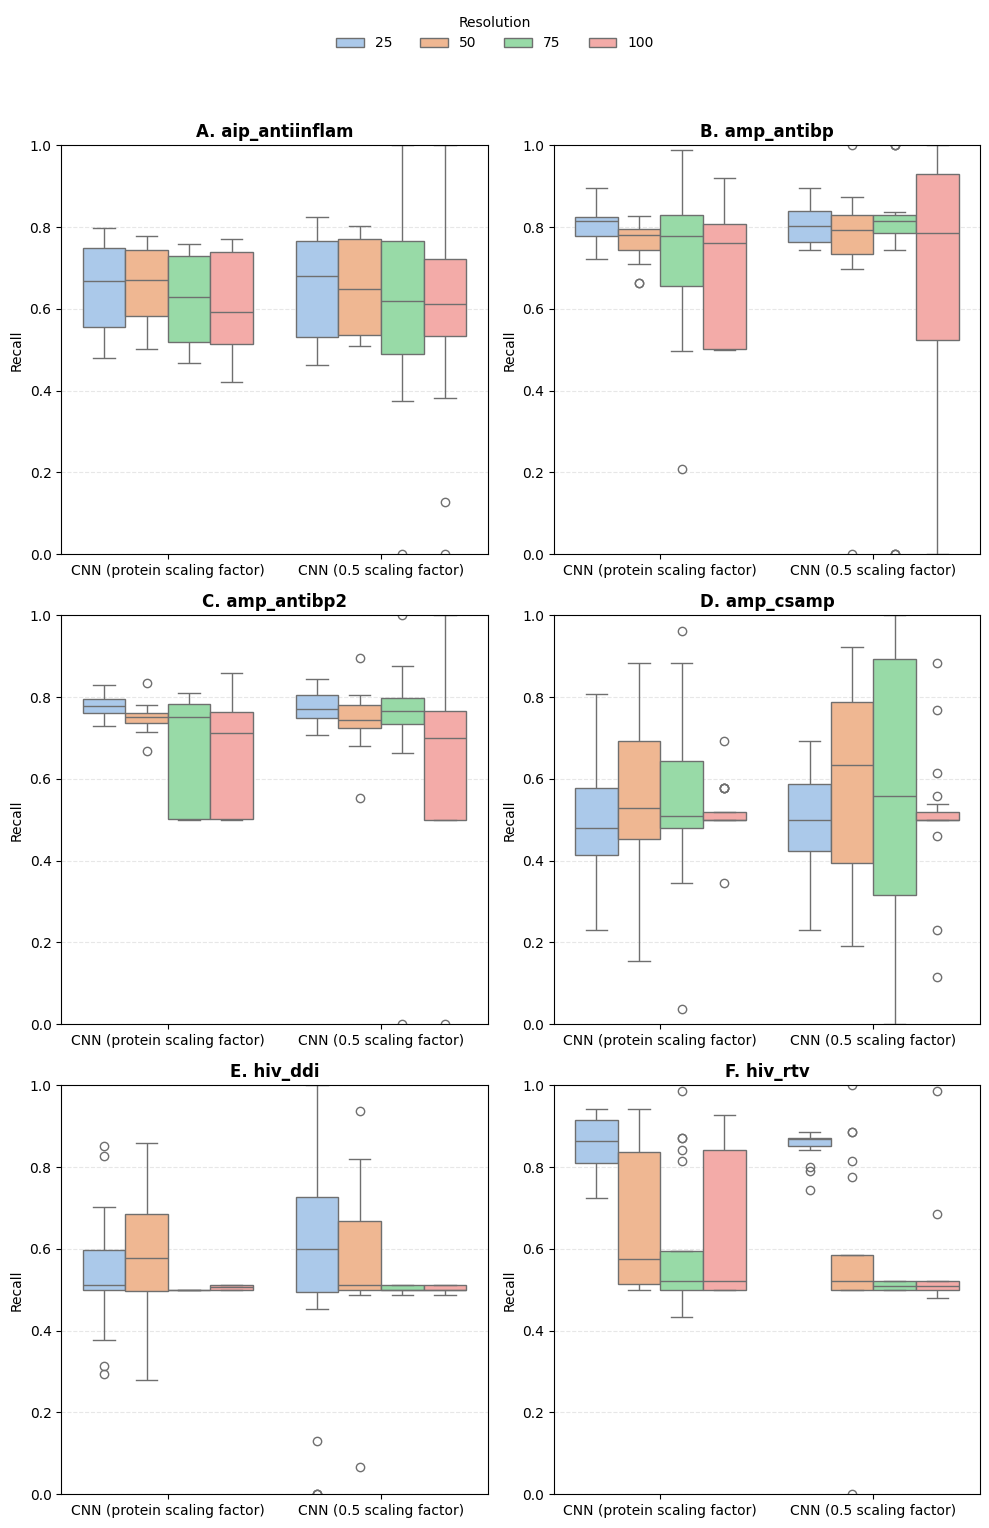

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
file_paths = ["reports/nosf/classification_results3_CNN.json", "reports/classification_results3_CNN.json"]

data = []

# Read and process each file
for file_path in file_paths:
    with open(file_path, "r") as f:
        results = json.load(f)

    # Extract model name from file name
    if "nosf/" in file_path:
        model_name = "CNN (protein scaling factor)"  # Adjusted model name for nosf file path meaning protein scale factor
    else:
        model_name = "CNN (0.5 scaling factor)"  # Adjusted model name for 0.5 sf

    for entry in results:
        dataset_name = "_".join(entry["dataset"].split("_")[:-1])
        resolution = entry["dataset"].split("_")[-1]
        for fold_metric in entry["fold_metrics"]:
            for label, metrics in fold_metric.items():
                data.append({
                    "Dataset": dataset_name,
                    "Model": model_name,
                    "Resolution": resolution,
                    "Class": label,
                    "Score": metrics["recall"]
                })

# Convert to DataFrame
df = pd.DataFrame(data)
df = df[df["Dataset"] != "hiv_lpv"]    # Exclude 'hiv_lpv' since some files still have it

# Get unique datasets
datasets = df["Dataset"].unique()

# Create a grid of subplots (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(10, 15))    
axes = axes.flatten()    

  
labels = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
resolution_order = ["25", "50", "75", "100"]
# Plot each dataset in a separate subplot
for i, dataset in enumerate(datasets):
    if i < len(axes):    
        sns.boxplot(
            x="Model", y="Score", hue="Resolution", hue_order=resolution_order,
            data=df[df["Dataset"] == dataset], palette="pastel", ax=axes[i]
        )
        axes[i].set_title(f"{labels[i]}. {dataset}", fontsize=12, fontweight="bold")
        axes[i].set_ylabel("Recall", fontsize=10)
        axes[i].set_xlabel("")
        axes[i].legend(title="Resolution", fontsize=8)
        axes[i].grid(alpha=0.3, linestyle="--", axis="y")
        axes[i].set_ylim(0.0, 1.0)
        axes[i].legend_.remove()      

  
for j in range(len(datasets), len(axes)):
    fig.delaxes(axes[j])

  
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, legend_labels,
    title="Resolution",
    loc="upper center",
    ncol=len(legend_labels),
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("boxplot/CNNvsCNNsf/CNN_vs_CNNsf_rec.pdf", bbox_inches='tight')
plt.show()

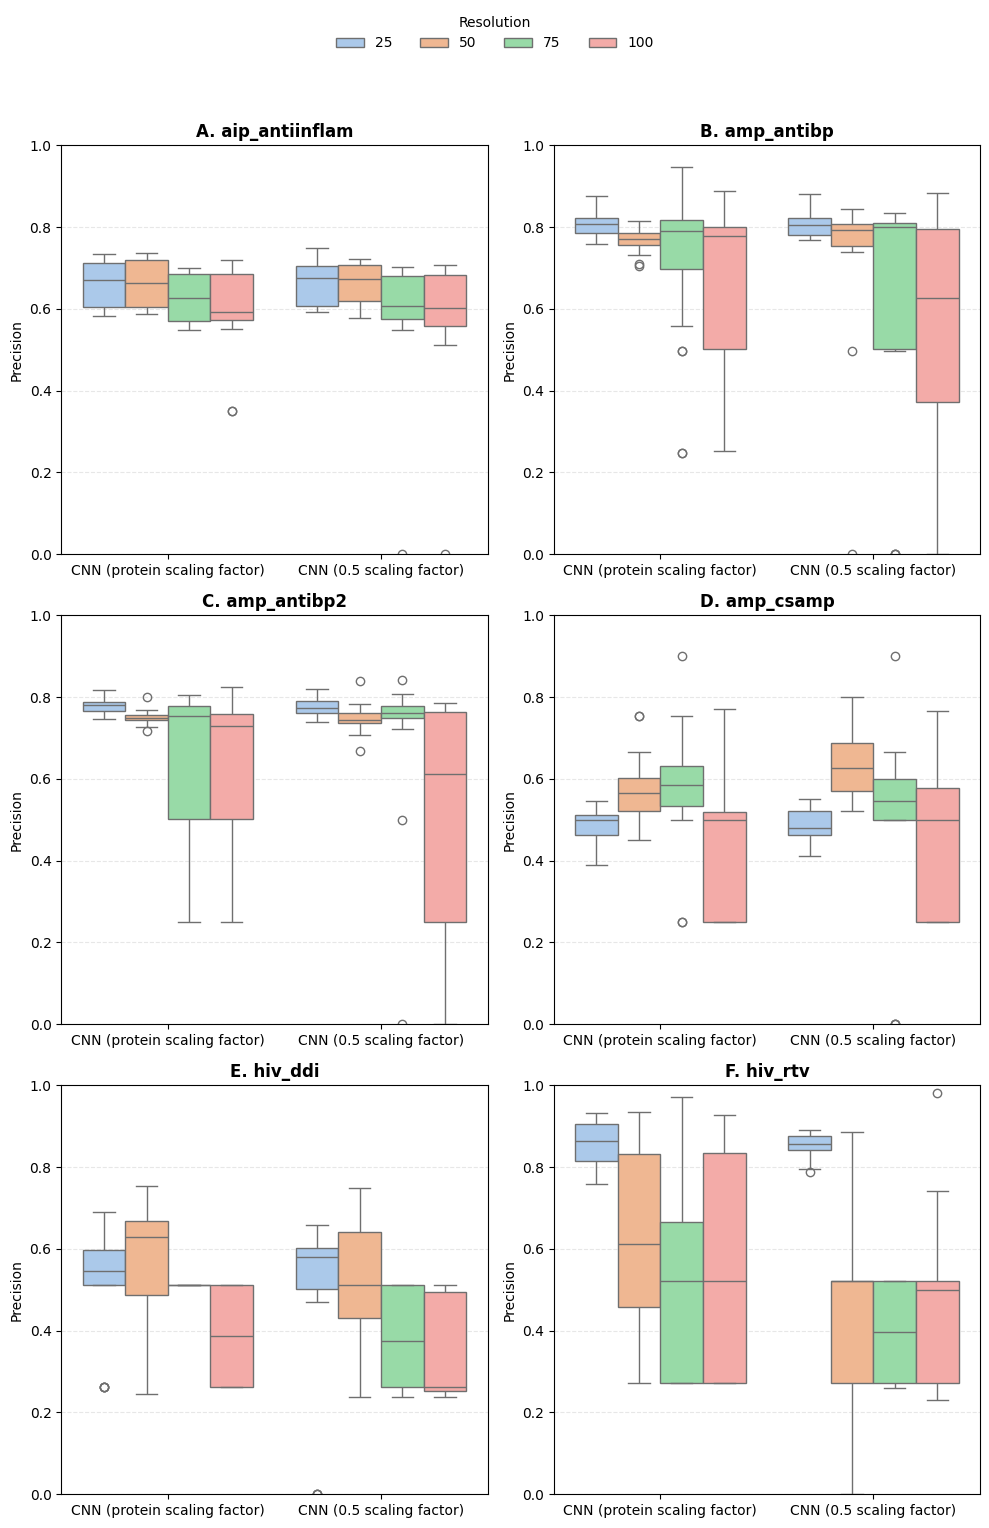

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
file_paths = ["reports/nosf/classification_results3_CNN.json", "reports/classification_results3_CNN.json"]

data = []

# Read and process each file
for file_path in file_paths:
    with open(file_path, "r") as f:
        results = json.load(f)

    # Extract model name from file name
    if "nosf/" in file_path:
        model_name = "CNN (protein scaling factor)"  # Adjusted model name for nosf file path meaning protein scale factor
    else:
        model_name = "CNN (0.5 scaling factor)"  # Adjusted model name for 0.5 sf

    for entry in results:
        dataset_name = "_".join(entry["dataset"].split("_")[:-1])
        resolution = entry["dataset"].split("_")[-1]
        for fold_metric in entry["fold_metrics"]:
            for label, metrics in fold_metric.items():
                data.append({
                    "Dataset": dataset_name,
                    "Model": model_name,
                    "Resolution": resolution,
                    "Class": label,
                    "Score": metrics["precision"]
                })

# Convert to DataFrame
df = pd.DataFrame(data)
df = df[df["Dataset"] != "hiv_lpv"]    # Exclude 'hiv_lpv' since some files still have it

# Get unique datasets
datasets = df["Dataset"].unique()

# Create a grid of subplots (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(10, 15))    
axes = axes.flatten()    

  
labels = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
resolution_order = ["25", "50", "75", "100"]
# Plot each dataset in a separate subplot
for i, dataset in enumerate(datasets):
    if i < len(axes):    
        sns.boxplot(
            x="Model", y="Score", hue="Resolution", hue_order=resolution_order,
            data=df[df["Dataset"] == dataset], palette="pastel", ax=axes[i]
        )
        axes[i].set_title(f"{labels[i]}. {dataset}", fontsize=12, fontweight="bold")
        axes[i].set_ylabel("Precision", fontsize=10)
        axes[i].set_xlabel("")
        axes[i].legend(title="Resolution", fontsize=8)
        axes[i].grid(alpha=0.3, linestyle="--", axis="y")
        axes[i].set_ylim(0.0, 1.0)
        axes[i].legend_.remove()      

  
for j in range(len(datasets), len(axes)):
    fig.delaxes(axes[j])

  
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, legend_labels,
    title="Resolution",
    loc="upper center",
    ncol=len(legend_labels),
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("boxplot/CNNvsCNNsf/CNN_vs_CNNsf_prec.pdf", bbox_inches='tight')
plt.show()

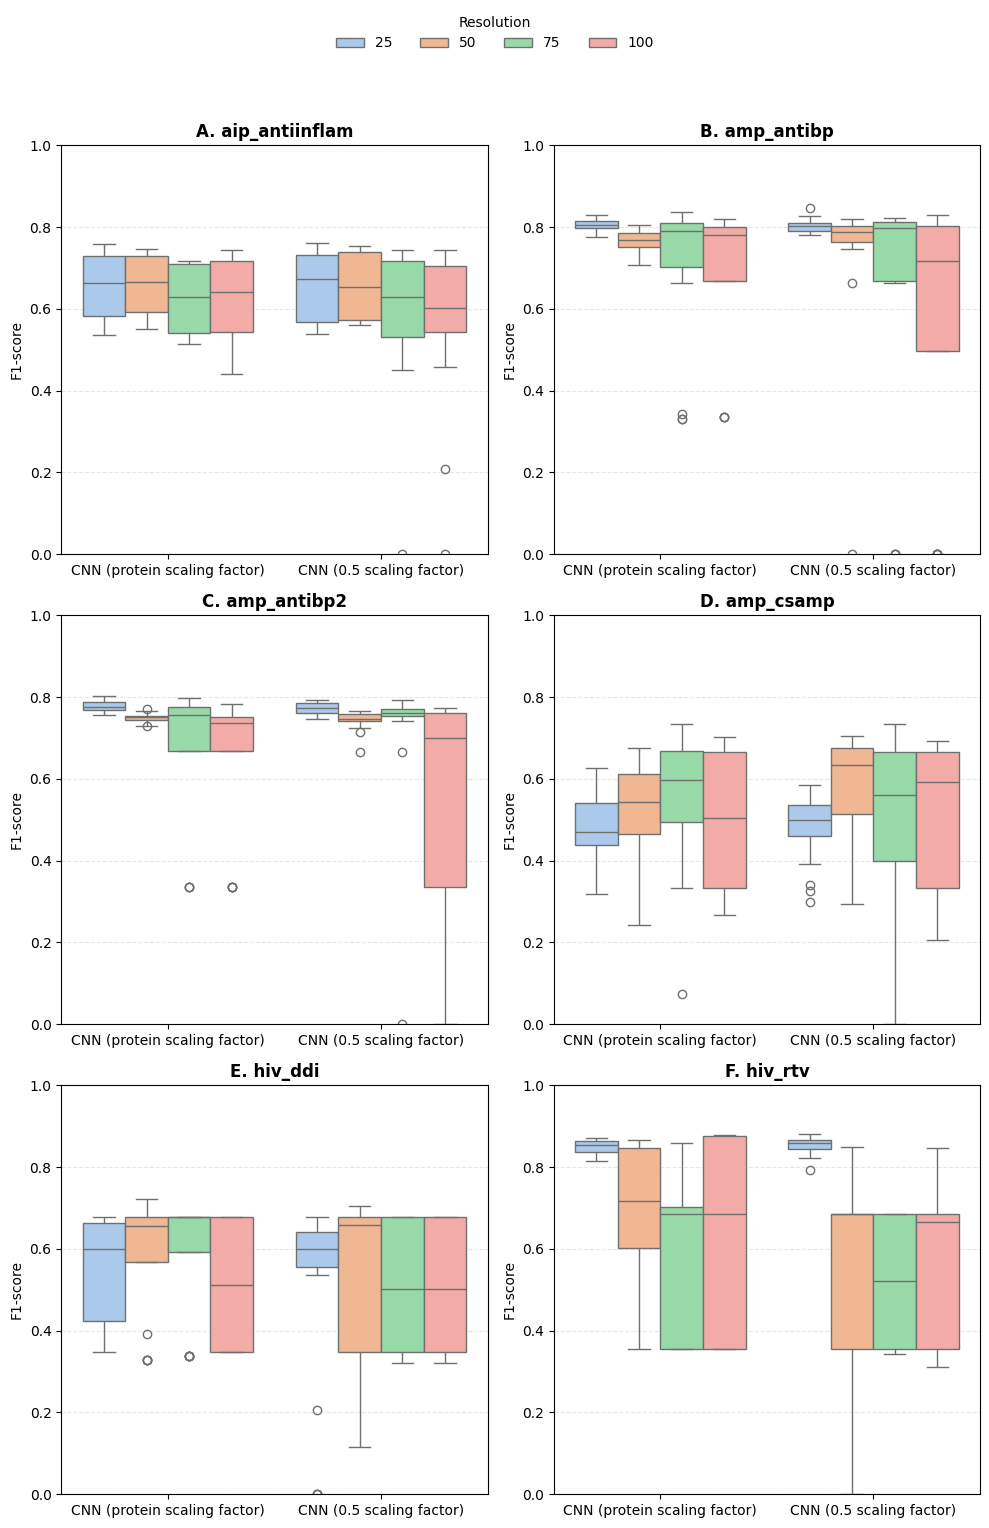

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
file_paths = ["reports/nosf/classification_results3_CNN.json", "reports/classification_results3_CNN.json"]

data = []

# Read and process each file
for file_path in file_paths:
    with open(file_path, "r") as f:
        results = json.load(f)

    # Extract model name from file name
    if "nosf/" in file_path:
        model_name = "CNN (protein scaling factor)"  # Adjusted model name for nosf file path meaning protein scale factor 
    else:
        model_name = "CNN (0.5 scaling factor)"  # Adjusted model name for 0.5 sf

    for entry in results:
        dataset_name = "_".join(entry["dataset"].split("_")[:-1])
        resolution = entry["dataset"].split("_")[-1]
        for fold_metric in entry["fold_metrics"]:
            for label, metrics in fold_metric.items():
                data.append({
                    "Dataset": dataset_name,
                    "Model": model_name,
                    "Resolution": resolution,
                    "Class": label,
                    "Score": metrics["f1-score"]
                })

# Convert to DataFrame
df = pd.DataFrame(data)
df = df[df["Dataset"] != "hiv_lpv"]    # Exclude 'hiv_lpv' since some files still have it

# Get unique datasets
datasets = df["Dataset"].unique()

# Create a grid of subplots (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(10, 15))    
axes = axes.flatten()    

  
labels = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
resolution_order = ["25", "50", "75", "100"]
# Plot each dataset in a separate subplot
for i, dataset in enumerate(datasets):
    if i < len(axes):    
        sns.boxplot(
            x="Model", y="Score", hue="Resolution", hue_order=resolution_order,
            data=df[df["Dataset"] == dataset], palette="pastel", ax=axes[i]
        )
        axes[i].set_title(f"{labels[i]}. {dataset}", fontsize=12, fontweight="bold")
        axes[i].set_ylabel("F1-score", fontsize=10)
        axes[i].set_xlabel("")
        axes[i].legend(title="Resolution", fontsize=8)
        axes[i].grid(alpha=0.3, linestyle="--", axis="y")
        axes[i].set_ylim(0.0, 1.0)
        axes[i].legend_.remove()      

  
for j in range(len(datasets), len(axes)):
    fig.delaxes(axes[j])

  
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, legend_labels,
    title="Resolution",
    loc="upper center",
    ncol=len(legend_labels),
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("boxplot/CNNvsCNNsf/CNN_vs_CNNsf_f1.pdf", bbox_inches='tight')
plt.show()

### Comparing cnn sf protein with fnn sf protein

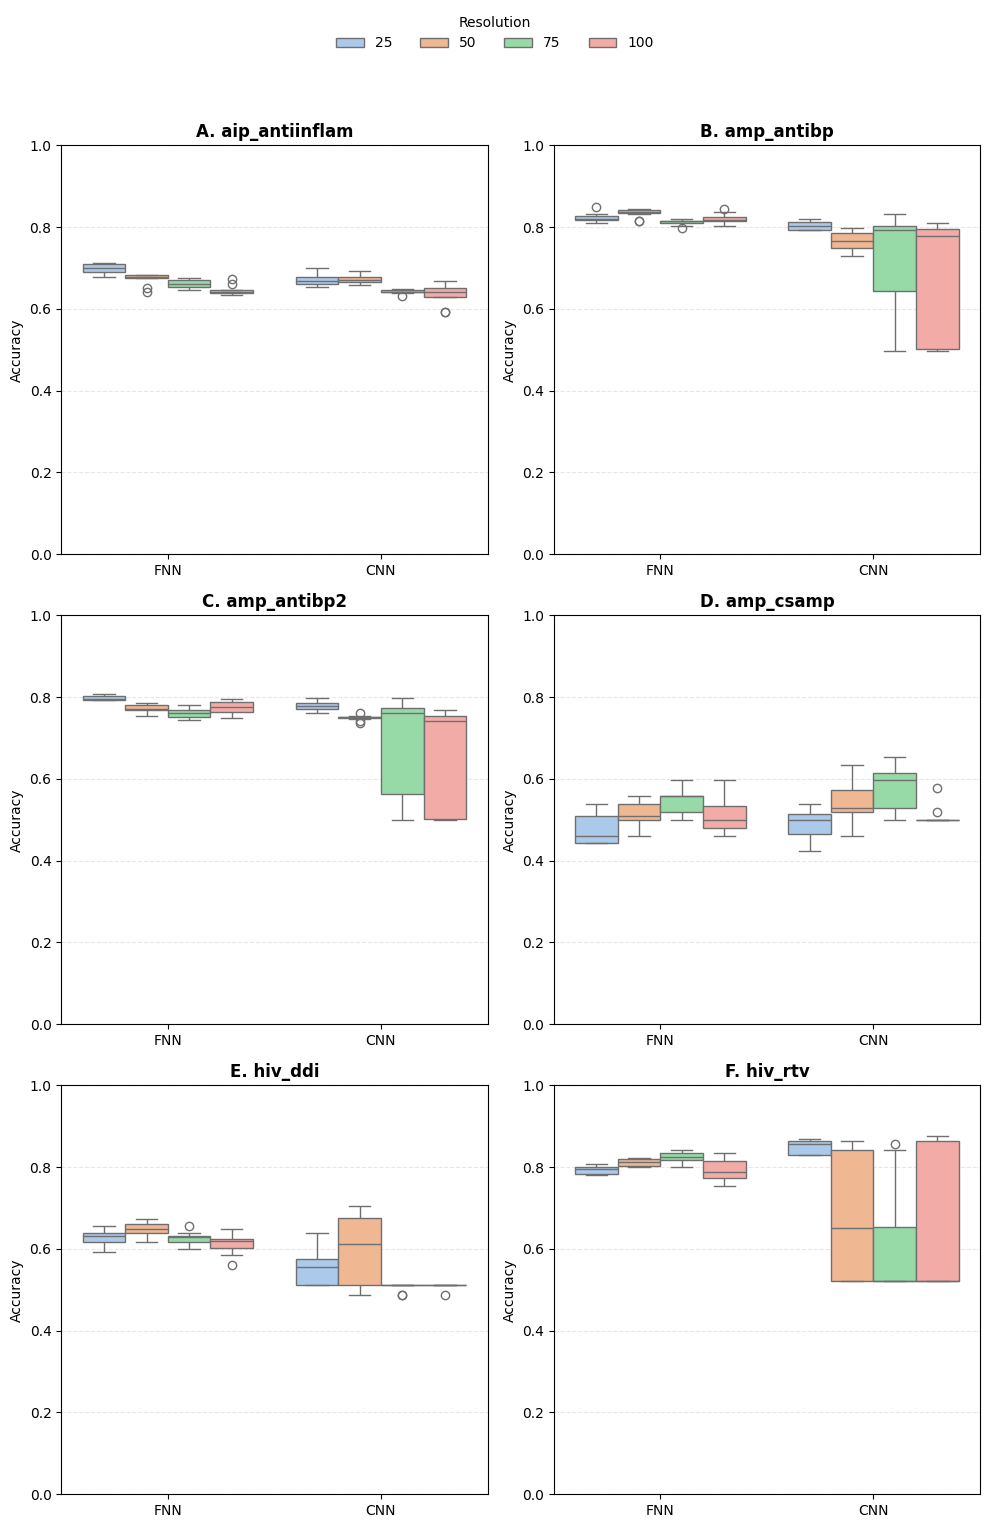

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
file_paths = ["reports/nosf/classification_results2_FNN.json", "reports/nosf/classification_results3_CNN.json"]

data = []

# Read and process each file
for file_path in file_paths:
    with open(file_path, "r") as f:
        results = json.load(f)

    # Extract model name from file name
    model_name = file_path.split("_")[-1].split(".")[0][-3:]    

    for entry in results:
        dataset_name = "_".join(entry["dataset"].split("_")[:-1])
        resolution = entry["dataset"].split("_")[-1]

        for acc in entry["accuracies"]:
            data.append({
                "Dataset": dataset_name,
                "Model": model_name,
                "Resolution": resolution,
                "Score": acc
            })

# Create DataFrame
df = pd.DataFrame(data)

df = df[df["Dataset"] != "hiv_lpv"]    # Exclude 'hiv_lpv' since some files still have it

# Get unique datasets
datasets = df["Dataset"].unique()

# Create a grid of subplots (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(10, 15))    
axes = axes.flatten()    

  
labels = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
resolution_order = ["25", "50", "75", "100"]
# Plot each dataset in a separate subplot
for i, dataset in enumerate(datasets):
    if i < len(axes):    
        sns.boxplot(
            x="Model", y="Score", hue="Resolution", hue_order=resolution_order,
            data=df[df["Dataset"] == dataset], palette="pastel", ax=axes[i]
        )
        axes[i].set_title(f"{labels[i]}. {dataset}", fontsize=12, fontweight="bold")
        axes[i].set_ylabel("Accuracy", fontsize=10)
        axes[i].set_xlabel("")
        axes[i].legend(title="Resolution", fontsize=8)
        axes[i].grid(alpha=0.3, linestyle="--", axis="y")
        axes[i].set_ylim(0.0, 1.0)
        axes[i].legend_.remove()      

  
for j in range(len(datasets), len(axes)):
    fig.delaxes(axes[j])

  
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, legend_labels,
    title="Resolution",
    loc="upper center",
    ncol=len(legend_labels),
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("boxplot/FNNsfvsCNNsf/FNNsf_vs_CNNsf_acc.pdf", bbox_inches='tight')
plt.show()

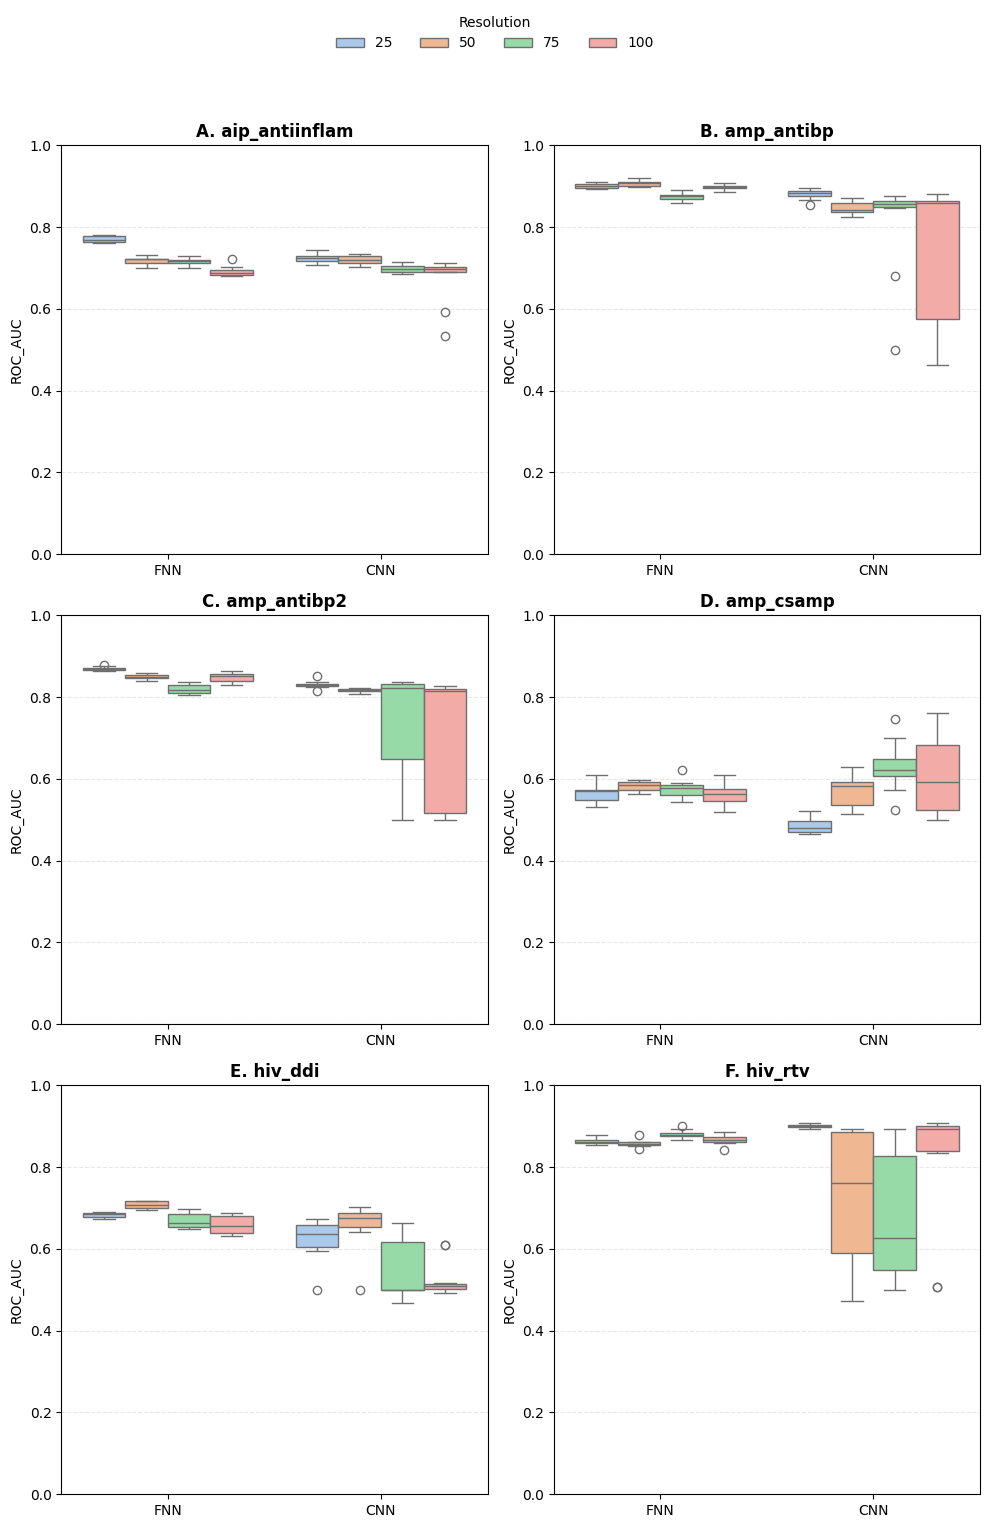

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
file_paths = ["reports/nosf/classification_results2_FNN.json", "reports/nosf/classification_results3_CNN.json"]

data = []

# Read and process each file
for file_path in file_paths:
    with open(file_path, "r") as f:
        results = json.load(f)

    # Extract model name from file name
    model_name = file_path.split("_")[-1].split(".")[0][-3:]    

    for entry in results:
        dataset_name = "_".join(entry["dataset"].split("_")[:-1])
        resolution = entry["dataset"].split("_")[-1]

        for auc in entry["roc_aucs"]:
            data.append({
                "Dataset": dataset_name,
                "Model": model_name,
                "Resolution": resolution,
                "Score": auc
            })

# Create DataFrame
df = pd.DataFrame(data)

df = df[df["Dataset"] != "hiv_lpv"]    # Exclude 'hiv_lpv' since some files still have it

# Get unique datasets
datasets = df["Dataset"].unique()

# Create a grid of subplots (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(10, 15))    
axes = axes.flatten()    

  
labels = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
resolution_order = ["25", "50", "75", "100"]
# Plot each dataset in a separate subplot
for i, dataset in enumerate(datasets):
    if i < len(axes):    
        sns.boxplot(
            x="Model", y="Score", hue="Resolution", hue_order=resolution_order,
            data=df[df["Dataset"] == dataset], palette="pastel", ax=axes[i]
        )
        axes[i].set_title(f"{labels[i]}. {dataset}", fontsize=12, fontweight="bold")
        axes[i].set_ylabel("ROC_AUC", fontsize=10)
        axes[i].set_xlabel("")
        axes[i].legend(title="Resolution", fontsize=8)
        axes[i].grid(alpha=0.3, linestyle="--", axis="y")
        axes[i].set_ylim(0.0, 1.0)
        axes[i].legend_.remove()      

  
for j in range(len(datasets), len(axes)):
    fig.delaxes(axes[j])

  
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, legend_labels,
    title="Resolution",
    loc="upper center",
    ncol=len(legend_labels),
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("boxplot/FNNsfvsCNNsf/FNNsf_vs_CNNsf_auc.pdf", bbox_inches='tight')
plt.show()

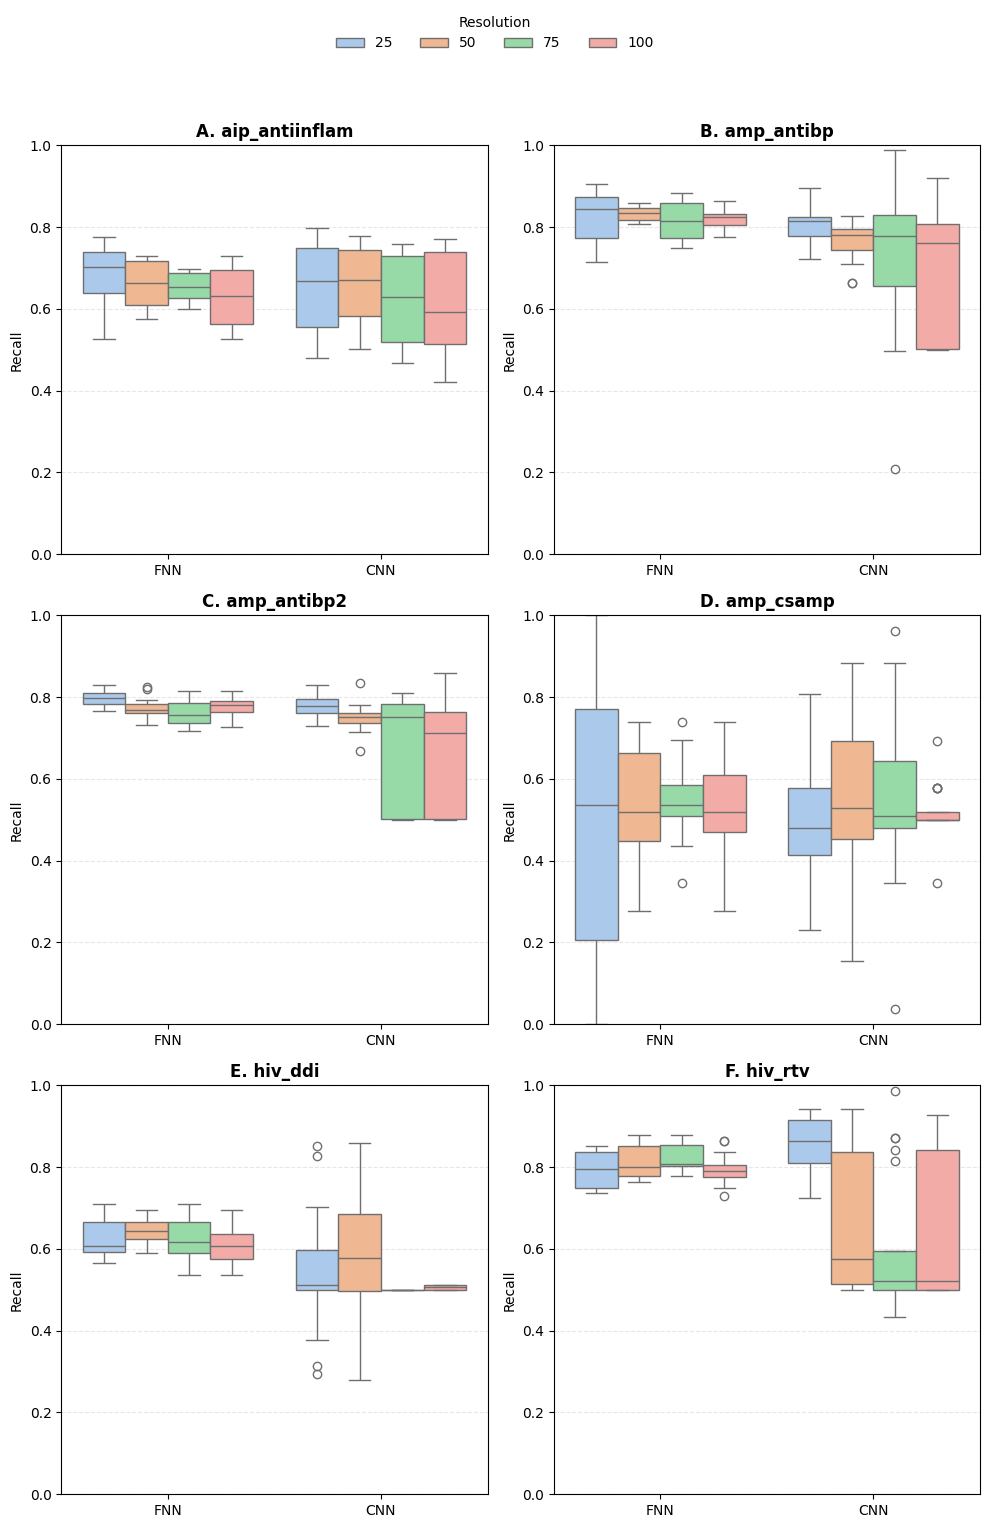

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
file_paths = ["reports/nosf/classification_results2_FNN.json", "reports/nosf/classification_results3_CNN.json"]

data = []

# Read and process each file
for file_path in file_paths:
    with open(file_path, "r") as f:
        results = json.load(f)

    # Extract model name from file name
    model_name = file_path.split("_")[-1].split(".")[0][-3:]    

    for entry in results:
        dataset_name = "_".join(entry["dataset"].split("_")[:-1])
        resolution = entry["dataset"].split("_")[-1]
        for fold_metric in entry["fold_metrics"]:
            for label, metrics in fold_metric.items():
                data.append({
                    "Dataset": dataset_name,
                    "Model": model_name,
                    "Resolution": resolution,
                    "Class": label,
                    "Score": metrics["recall"]
                })

# Convert to DataFrame
df = pd.DataFrame(data)
df = df[df["Dataset"] != "hiv_lpv"]    # Exclude 'hiv_lpv' since some files still have it

# Get unique datasets
datasets = df["Dataset"].unique()

# Create a grid of subplots (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(10, 15))    
axes = axes.flatten()    

  
labels = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
resolution_order = ["25", "50", "75", "100"]
# Plot each dataset in a separate subplot
for i, dataset in enumerate(datasets):
    if i < len(axes):    
        sns.boxplot(
            x="Model", y="Score", hue="Resolution", hue_order=resolution_order,
            data=df[df["Dataset"] == dataset], palette="pastel", ax=axes[i]
        )
        axes[i].set_title(f"{labels[i]}. {dataset}", fontsize=12, fontweight="bold")
        axes[i].set_ylabel("Recall", fontsize=10)
        axes[i].set_xlabel("")
        axes[i].legend(title="Resolution", fontsize=8)
        axes[i].grid(alpha=0.3, linestyle="--", axis="y")
        axes[i].set_ylim(0.0, 1.0)
        axes[i].legend_.remove()      

  
for j in range(len(datasets), len(axes)):
    fig.delaxes(axes[j])

  
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, legend_labels,
    title="Resolution",
    loc="upper center",
    ncol=len(legend_labels),
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("boxplot/FNNsfvsCNNsf/FNNsf_vs_CNNsf_rec.pdf", bbox_inches='tight')
plt.show()

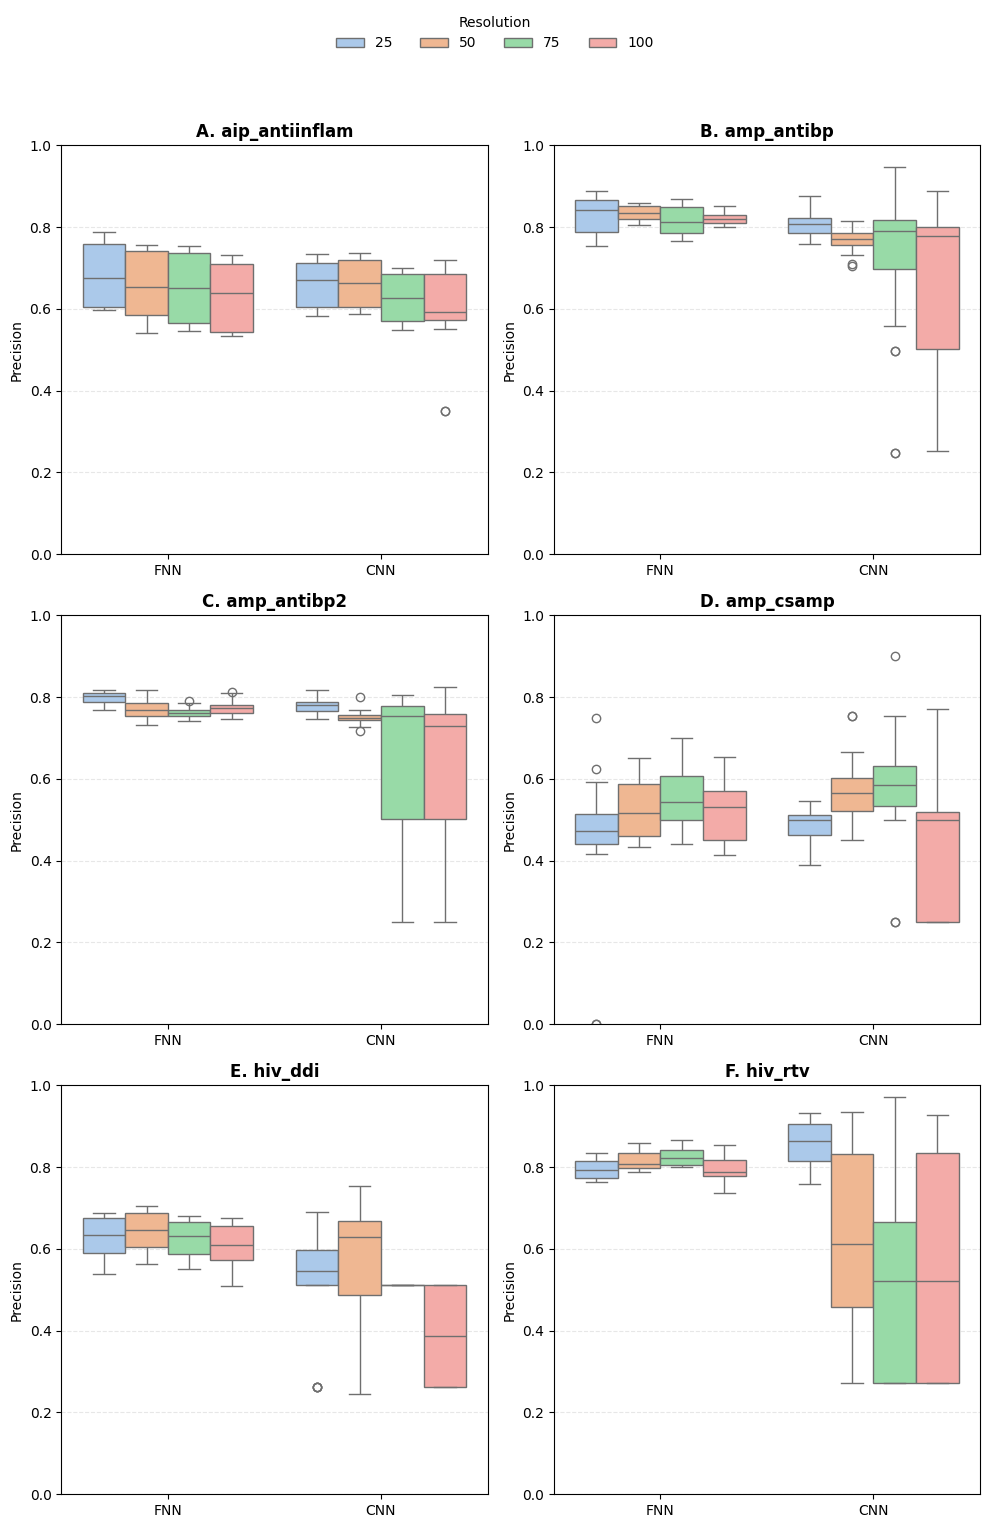

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
file_paths = ["reports/nosf/classification_results2_FNN.json", "reports/nosf/classification_results3_CNN.json"]

data = []

# Read and process each file
for file_path in file_paths:
    with open(file_path, "r") as f:
        results = json.load(f)

    # Extract model name from file name
    model_name = file_path.split("_")[-1].split(".")[0][-3:]    

    for entry in results:
        dataset_name = "_".join(entry["dataset"].split("_")[:-1])
        resolution = entry["dataset"].split("_")[-1]
        for fold_metric in entry["fold_metrics"]:
            for label, metrics in fold_metric.items():
                data.append({
                    "Dataset": dataset_name,
                    "Model": model_name,
                    "Resolution": resolution,
                    "Class": label,
                    "Score": metrics["precision"]
                })

# Convert to DataFrame
df = pd.DataFrame(data)
df = df[df["Dataset"] != "hiv_lpv"]    # Exclude 'hiv_lpv' since some files still have it

# Get unique datasets
datasets = df["Dataset"].unique()

# Create a grid of subplots (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(10, 15))    
axes = axes.flatten()    

  
labels = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
resolution_order = ["25", "50", "75", "100"]
# Plot each dataset in a separate subplot
for i, dataset in enumerate(datasets):
    if i < len(axes):    
        sns.boxplot(
            x="Model", y="Score", hue="Resolution", hue_order=resolution_order,
            data=df[df["Dataset"] == dataset], palette="pastel", ax=axes[i]
        )
        axes[i].set_title(f"{labels[i]}. {dataset}", fontsize=12, fontweight="bold")
        axes[i].set_ylabel("Precision", fontsize=10)
        axes[i].set_xlabel("")
        axes[i].legend(title="Resolution", fontsize=8)
        axes[i].grid(alpha=0.3, linestyle="--", axis="y")
        axes[i].set_ylim(0.0, 1.0)
        axes[i].legend_.remove()      

  
for j in range(len(datasets), len(axes)):
    fig.delaxes(axes[j])

  
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, legend_labels,
    title="Resolution",
    loc="upper center",
    ncol=len(legend_labels),
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("boxplot/FNNsfvsCNNsf/FNNsf_vs_CNNsf_prec.pdf", bbox_inches='tight')
plt.show()

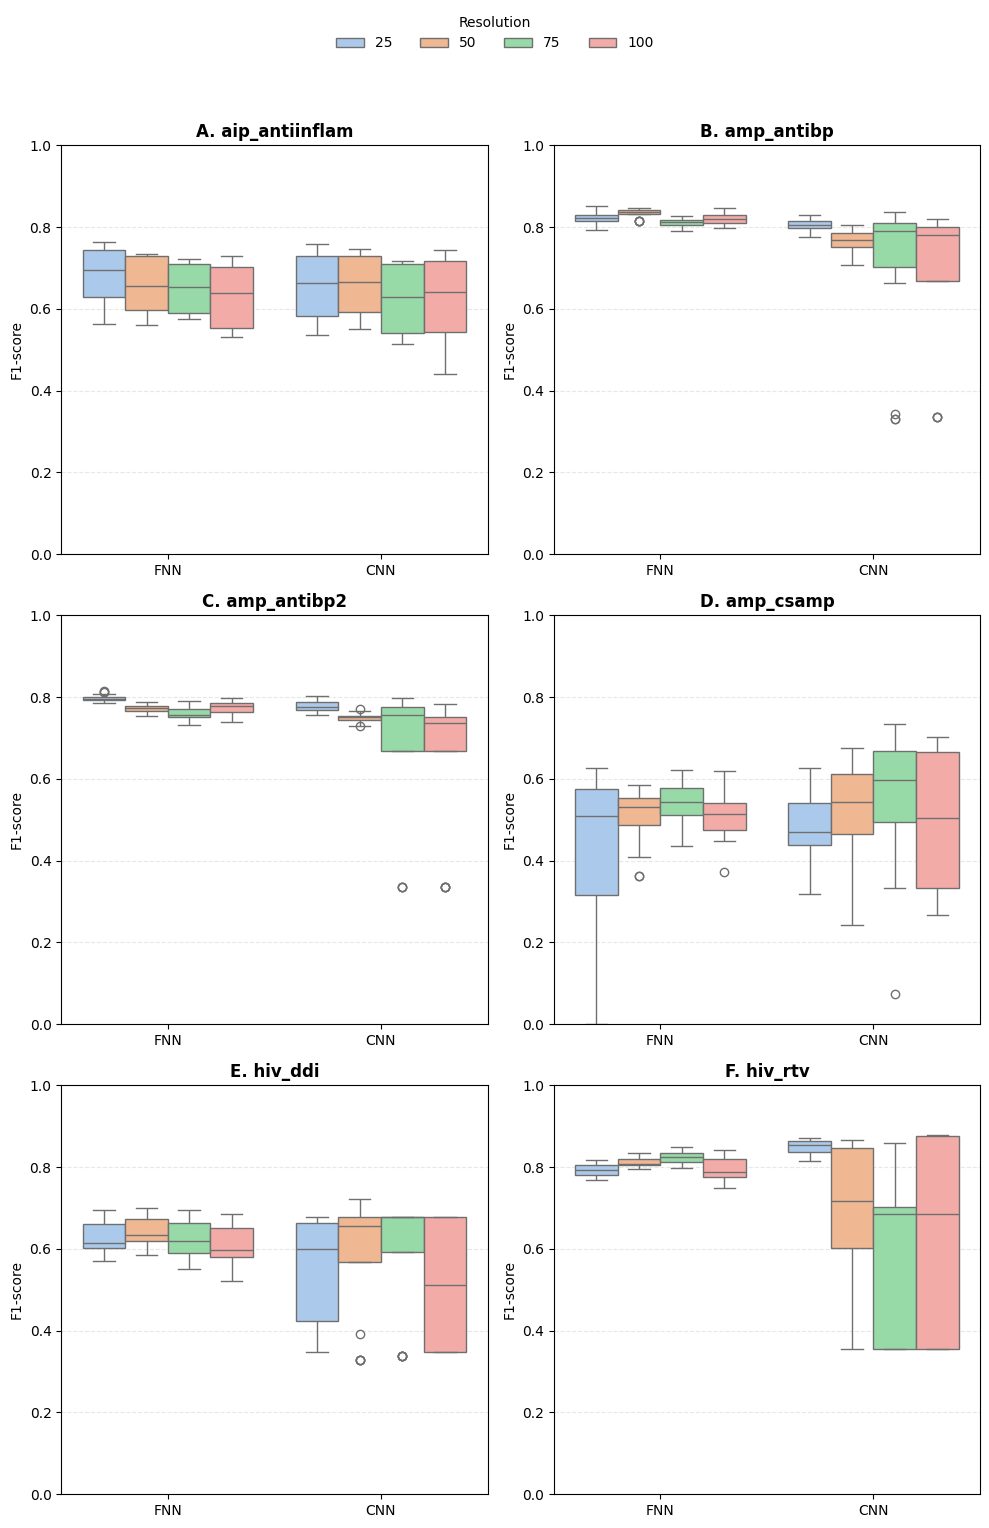

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
file_paths = ["reports/nosf/classification_results2_FNN.json", "reports/nosf/classification_results3_CNN.json"]

data = []

# Read and process each file
for file_path in file_paths:
    with open(file_path, "r") as f:
        results = json.load(f)

    # Extract model name from file name
    model_name = file_path.split("_")[-1].split(".")[0][-3:]    

    for entry in results:
        dataset_name = "_".join(entry["dataset"].split("_")[:-1])
        resolution = entry["dataset"].split("_")[-1]
        for fold_metric in entry["fold_metrics"]:
            for label, metrics in fold_metric.items():
                data.append({
                    "Dataset": dataset_name,
                    "Model": model_name,
                    "Resolution": resolution,
                    "Class": label,
                    "Score": metrics["f1-score"]
                })

# Convert to DataFrame
df = pd.DataFrame(data)
df = df[df["Dataset"] != "hiv_lpv"]    # Exclude 'hiv_lpv' since some files still have it

# Get unique datasets
datasets = df["Dataset"].unique()

# Create a grid of subplots (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(10, 15))    
axes = axes.flatten()    

  
labels = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
resolution_order = ["25", "50", "75", "100"]
# Plot each dataset in a separate subplot
for i, dataset in enumerate(datasets):
    if i < len(axes):    
        sns.boxplot(
            x="Model", y="Score", hue="Resolution", hue_order=resolution_order,
            data=df[df["Dataset"] == dataset], palette="pastel", ax=axes[i]
        )
        axes[i].set_title(f"{labels[i]}. {dataset}", fontsize=12, fontweight="bold")
        axes[i].set_ylabel("F1-score", fontsize=10)
        axes[i].set_xlabel("")
        axes[i].legend(title="Resolution", fontsize=8)
        axes[i].grid(alpha=0.3, linestyle="--", axis="y")
        axes[i].set_ylim(0.0, 1.0)
        axes[i].legend_.remove()      

  
for j in range(len(datasets), len(axes)):
    fig.delaxes(axes[j])

  
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, legend_labels,
    title="Resolution",
    loc="upper center",
    ncol=len(legend_labels),
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("boxplot/FNNsfvsCNNsf/FNNsf_vs_CNNsf_f1.pdf", bbox_inches='tight')
plt.show()

### Which sf is better for each dataset 

C:\Users\User\AppData\Local\Temp\ipykernel_1908\2030296198.py:38: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_wide = df.pivot_table(
C:\Users\User\AppData\Local\Temp\ipykernel_1908\2030296198.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med = df_wide.groupby(["Model","Dataset","Resolution"])["Delta"]\


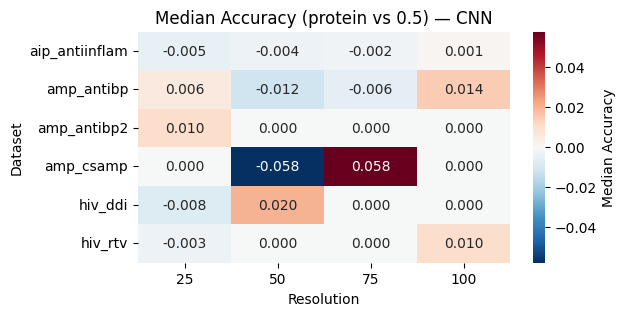

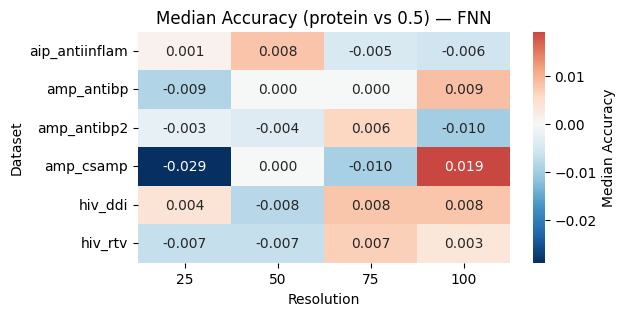

In [ ]:
#Positive means protein scaling is better negative means the 0.5 scaling is better by difference = acc(protein) - acc(0.5)

import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_df(path, model, scaling):
    records = []
    data = json.load(open(path))
    for e in data:
        ds, res = e["dataset"].rsplit("_", 1)
        for fold_idx, acc in enumerate(e["accuracies"]):
            records.append({
                "Dataset":     ds,
                "Resolution":  res,
                "Fold":        fold_idx,
                "Accuracy":    acc,
                "Scaling":     scaling,
                "Model":       model
            })
    return pd.DataFrame(records)

# Load all four files
df = pd.concat([
    load_df("reports/nosf/classification_results2_FNN.json",  "FNN", "protein"),
    load_df("reports/classification_results2_FNN.json",      "FNN", "0.5"),
    load_df("reports/nosf/classification_results3_CNN.json", "CNN", "protein"),
    load_df("reports/classification_results3_CNN.json",     "CNN", "0.5"),
], ignore_index=True)

df = df[df["Dataset"] != "hiv_lpv"]

 
df["Resolution"] = pd.Categorical(df["Resolution"], categories=["25", "50", "75", "100"], ordered=True)

# Pivot to get protein and 0.5 side by side
df_wide = df.pivot_table(
    index=["Model","Dataset","Resolution","Fold"],
    columns="Scaling", values="Accuracy"
).reset_index()

# Compute difference
df_wide["Delta"] = df_wide["protein"] - df_wide["0.5"]

# Median difference by Model, Dataset, Resolution
med = df_wide.groupby(["Model","Dataset","Resolution"])["Delta"]\
             .median()\
             .unstack(level="Resolution")\
             .reset_index()

# Plot heatmap per model
for model in med["Model"].unique():
    sub = med[med["Model"] == model].set_index("Dataset").drop(columns="Model")
    plt.figure(figsize=(6, 3))
    sns.heatmap(
        sub, annot=True, fmt=".3f", center=0,
        cmap="RdBu_r", cbar_kws={"label":"Median Accuracy"}
    )
    plt.title(f"Median Accuracy (protein vs 0.5) — {model}")
    plt.ylabel("Dataset")
    plt.xlabel("Resolution")
    plt.savefig(f"boxplot/{model}_acc.pdf", bbox_inches='tight')
    plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_1908\1972846459.py:38: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_wide = df.pivot_table(
C:\Users\User\AppData\Local\Temp\ipykernel_1908\1972846459.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med = df_wide.groupby(["Model","Dataset","Resolution"])["Delta"]\


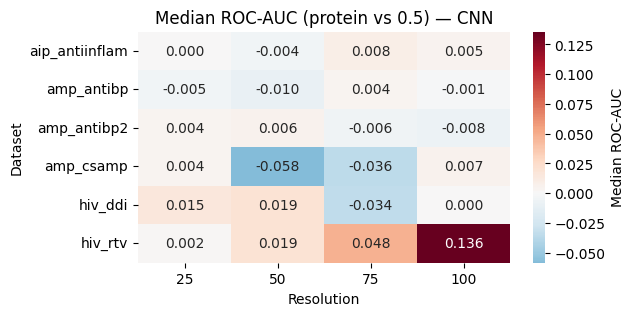

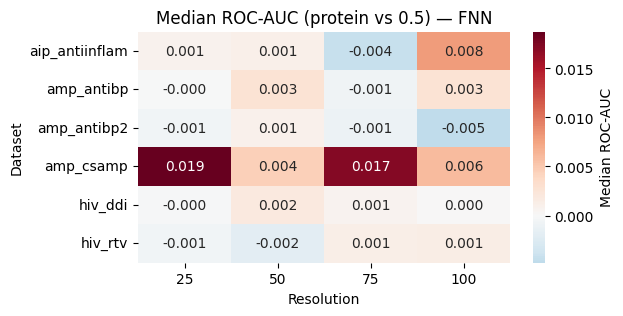

In [ ]:
#Positive means protein scaling is better negative means the 0.5 scaling is better by difference = acc(protein) - acc(0.5)

import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_df(path, model, scaling):
    records = []
    data = json.load(open(path))
    for e in data:
        ds, res = e["dataset"].rsplit("_", 1)
        for fold_idx, auc in enumerate(e["roc_aucs"]):
            records.append({
                "Dataset":     ds,
                "Resolution":  res,
                "Fold":        fold_idx,
                "ROC-AUC":    auc,
                "Scaling":     scaling,
                "Model":       model
            })
    return pd.DataFrame(records)

# Load all four files
df = pd.concat([
    load_df("reports/nosf/classification_results2_FNN.json",  "FNN", "protein"),
    load_df("reports/classification_results2_FNN.json",      "FNN", "0.5"),
    load_df("reports/nosf/classification_results3_CNN.json", "CNN", "protein"),
    load_df("reports/classification_results3_CNN.json",     "CNN", "0.5"),
], ignore_index=True)

df = df[df["Dataset"] != "hiv_lpv"]

 
df["Resolution"] = pd.Categorical(df["Resolution"], categories=["25", "50", "75", "100"], ordered=True)

# Pivot to get protein and 0.5 side by side
df_wide = df.pivot_table(
    index=["Model","Dataset","Resolution","Fold"],
    columns="Scaling", values="ROC-AUC"
).reset_index()

# Compute difference
df_wide["Delta"] = df_wide["protein"] - df_wide["0.5"]

# Median difference by Model, Dataset, Resolution
med = df_wide.groupby(["Model","Dataset","Resolution"])["Delta"]\
             .median()\
             .unstack(level="Resolution")\
             .reset_index()

# Plot heatmap per model
for model in med["Model"].unique():
    sub = med[med["Model"] == model].set_index("Dataset").drop(columns="Model")
    plt.figure(figsize=(6, 3))
    sns.heatmap(
        sub, annot=True, fmt=".3f", center=0,
        cmap="RdBu_r", cbar_kws={"label":"Median ROC-AUC"}
    )
    plt.title(f"Median ROC-AUC (protein vs 0.5) — {model}")
    plt.ylabel("Dataset")
    plt.xlabel("Resolution")
    plt.savefig(f"boxplot/{model}_auc.pdf", bbox_inches='tight')
    plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_1908\3914817842.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_wide = df.pivot_table(
C:\Users\User\AppData\Local\Temp\ipykernel_1908\3914817842.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med = df_wide.groupby(["Model","Dataset","Resolution"])["Delta"]\


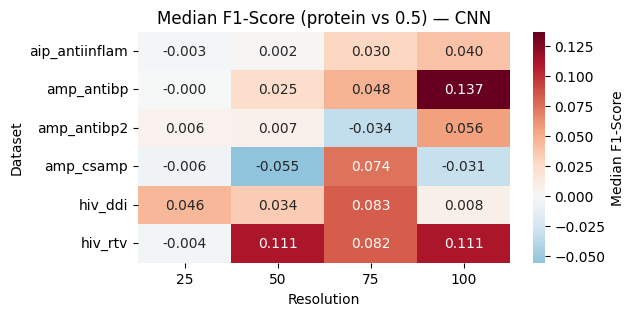

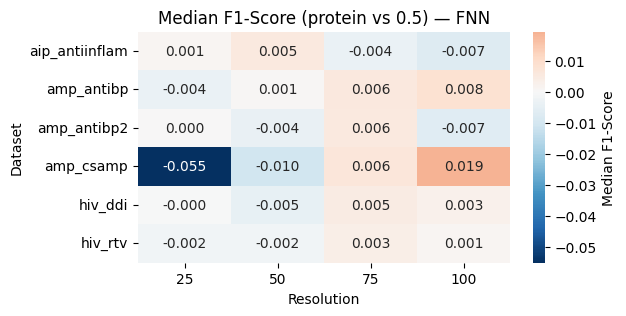

In [ ]:
#Positive means protein scaling is better negative means the 0.5 scaling is better by difference = acc(protein) - acc(0.5)

import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_df(path, model, scaling):
    records = []
    data = json.load(open(path))
    for e in data:
        ds, res = e["dataset"].rsplit("_", 1)
        for fold_metric in e["fold_metrics"]:
            for fold_idx, metrics in fold_metric.items():
                records.append({
                    "Dataset":     ds,
                    "Resolution":  res,
                    "Fold":        fold_idx,  
                    "F1-Score":    metrics.get("f1-score", 0),
                    "Scaling":     scaling,
                    "Model":       model
                })
    return pd.DataFrame(records)

# Load all four files
df = pd.concat([
    load_df("reports/nosf/classification_results2_FNN.json",  "FNN", "protein"),
    load_df("reports/classification_results2_FNN.json",      "FNN", "0.5"),
    load_df("reports/nosf/classification_results3_CNN.json", "CNN", "protein"),
    load_df("reports/classification_results3_CNN.json",     "CNN", "0.5"),
], ignore_index=True)

df = df[df["Dataset"] != "hiv_lpv"]

 
df["Resolution"] = pd.Categorical(df["Resolution"], categories=["25", "50", "75", "100"], ordered=True)

# Pivot to get protein and 0.5 side by side
df_wide = df.pivot_table(
    index=["Model","Dataset","Resolution","Fold"],
    columns="Scaling", values="F1-Score"
).reset_index()

# Compute difference
df_wide["Delta"] = df_wide["protein"] - df_wide["0.5"]

# Median difference by Model, Dataset, Resolution
med = df_wide.groupby(["Model","Dataset","Resolution"])["Delta"]\
             .median()\
             .unstack(level="Resolution")\
             .reset_index()

# Plot heatmap per model
for model in med["Model"].unique():
    sub = med[med["Model"] == model].set_index("Dataset").drop(columns="Model")
    plt.figure(figsize=(6, 3))
    sns.heatmap(
        sub, annot=True, fmt=".3f", center=0,
        cmap="RdBu_r", cbar_kws={"label":"Median F1-Score"}
    )
    plt.title(f"Median F1-Score (protein vs 0.5) — {model}")
    plt.ylabel("Dataset")
    plt.xlabel("Resolution")
    plt.savefig(f"boxplot/{model}_f1.pdf", bbox_inches='tight')
    plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_1908\1217435322.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_wide = df.pivot_table(
C:\Users\User\AppData\Local\Temp\ipykernel_1908\1217435322.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med = df_wide.groupby(["Model","Dataset","Resolution"])["Delta"]\


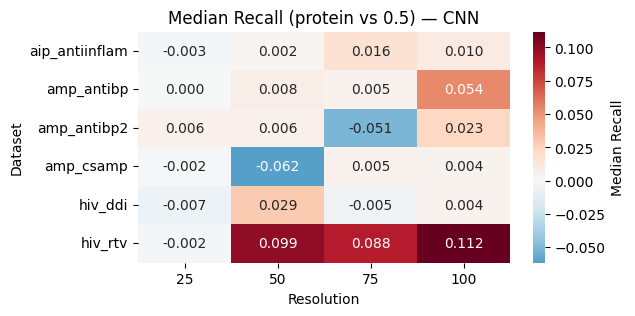

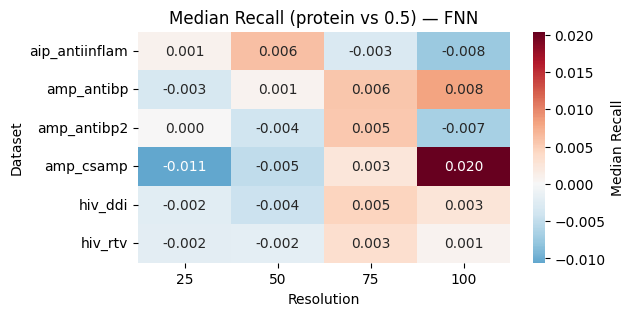

In [ ]:
#Positive means protein scaling is better negative means the 0.5 scaling is better by difference = acc(protein) - acc(0.5)

import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_df(path, model, scaling):
    records = []
    data = json.load(open(path))
    for e in data:
        ds, res = e["dataset"].rsplit("_", 1)
        for fold_metric in e["fold_metrics"]:
            for fold_idx, metrics in fold_metric.items():
                records.append({
                    "Dataset":     ds,
                    "Resolution":  res,
                    "Fold":        fold_idx,  
                    "Recall":    metrics.get("recall", 0),
                    "Scaling":     scaling,
                    "Model":       model
                })
    return pd.DataFrame(records)

# Load all four files
df = pd.concat([
    load_df("reports/nosf/classification_results2_FNN.json",  "FNN", "protein"),
    load_df("reports/classification_results2_FNN.json",      "FNN", "0.5"),
    load_df("reports/nosf/classification_results3_CNN.json", "CNN", "protein"),
    load_df("reports/classification_results3_CNN.json",     "CNN", "0.5"),
], ignore_index=True)

df = df[df["Dataset"] != "hiv_lpv"]

 
df["Resolution"] = pd.Categorical(df["Resolution"], categories=["25", "50", "75", "100"], ordered=True)

df_wide = df.pivot_table(
    index=["Model","Dataset","Resolution","Fold"],
    columns="Scaling", values="Recall"
).reset_index()

# Compute difference
df_wide["Delta"] = df_wide["protein"] - df_wide["0.5"]

# Median difference by Model, Dataset, Resolution
med = df_wide.groupby(["Model","Dataset","Resolution"])["Delta"]\
             .median()\
             .unstack(level="Resolution")\
             .reset_index()

# Plot heatmap per model
for model in med["Model"].unique():
    sub = med[med["Model"] == model].set_index("Dataset").drop(columns="Model")
    plt.figure(figsize=(6, 3))
    sns.heatmap(
        sub, annot=True, fmt=".3f", center=0,
        cmap="RdBu_r", cbar_kws={"label":"Median Recall"}
    )
    plt.title(f"Median Recall (protein vs 0.5) — {model}")
    plt.ylabel("Dataset")
    plt.xlabel("Resolution")
    plt.savefig(f"boxplot/{model}_rec.pdf", bbox_inches='tight')
    plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_1908\3192799946.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_wide = df.pivot_table(
C:\Users\User\AppData\Local\Temp\ipykernel_1908\3192799946.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med = df_wide.groupby(["Model","Dataset","Resolution"])["Delta"]\


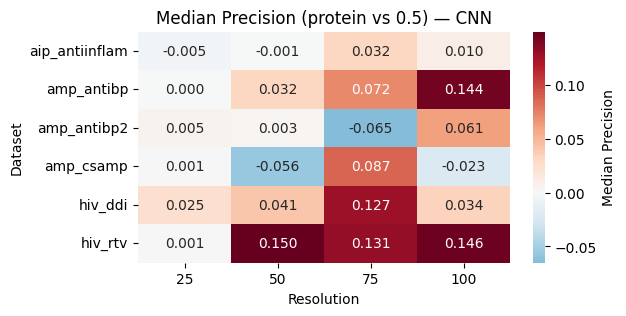

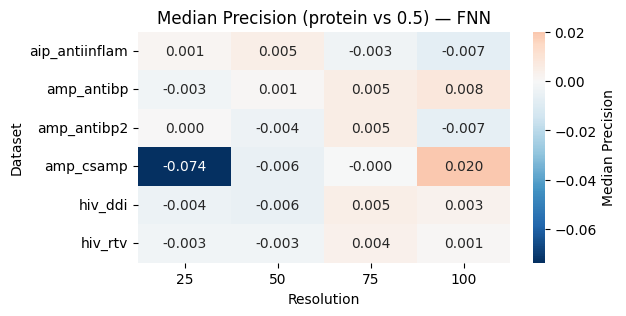

In [ ]:
#Positive means protein scaling is better negative means the 0.5 scaling is better by difference = acc(protein) - acc(0.5)

import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_df(path, model, scaling):
    records = []
    data = json.load(open(path))
    for e in data:
        ds, res = e["dataset"].rsplit("_", 1)
        for fold_metric in e["fold_metrics"]:
            for fold_idx, metrics in fold_metric.items():
                records.append({
                    "Dataset":     ds,
                    "Resolution":  res,
                    "Fold":        fold_idx, 
                    "Precision":    metrics.get("precision", 0),
                    "Scaling":     scaling,
                    "Model":       model
                })
    return pd.DataFrame(records)

# Load all four files
df = pd.concat([
    load_df("reports/nosf/classification_results2_FNN.json",  "FNN", "protein"),
    load_df("reports/classification_results2_FNN.json",      "FNN", "0.5"),
    load_df("reports/nosf/classification_results3_CNN.json", "CNN", "protein"),
    load_df("reports/classification_results3_CNN.json",     "CNN", "0.5"),
], ignore_index=True)

df = df[df["Dataset"] != "hiv_lpv"]

df["Resolution"] = pd.Categorical(df["Resolution"], categories=["25", "50", "75", "100"], ordered=True)

df_wide = df.pivot_table(
    index=["Model","Dataset","Resolution","Fold"],
    columns="Scaling", values="Precision"
).reset_index()

# Compute difference
df_wide["Delta"] = df_wide["protein"] - df_wide["0.5"]

# Median difference by Model, Dataset, Resolution
med = df_wide.groupby(["Model","Dataset","Resolution"])["Delta"]\
             .median()\
             .unstack(level="Resolution")\
             .reset_index()

# Plot heatmap per model
for model in med["Model"].unique():
    sub = med[med["Model"] == model].set_index("Dataset").drop(columns="Model")
    plt.figure(figsize=(6, 3))
    sns.heatmap(
        sub, annot=True, fmt=".3f", center=0,
        cmap="RdBu_r", cbar_kws={"label":"Median Precision"}
    )
    plt.title(f"Median Precision (protein vs 0.5) — {model}")
    plt.ylabel("Dataset")
    plt.xlabel("Resolution")
    plt.savefig(f"boxplot/{model}_prec.pdf", bbox_inches='tight')
    plt.show()


In [1]:
import json
import pandas as pd
def load_df(path):
    records = []
    data = json.load(open(path))
    for e in data:
        ds, res = e["dataset"].rsplit("_", 1)
        for fold_metric in e["fold_metrics"]:
            for fold_idx, metrics in fold_metric.items():
                record = {
                    "Dataset":     ds,
                    "Resolution":  res,
                }
                record.update(metrics)
                records.append(record)
    return pd.DataFrame(records)

df = pd.concat([
    load_df("reports/nosf/classification_results2_FNN.json"),
   ], ignore_index=True)

df = df[df["Dataset"] != "hiv_lpv"]

max_metrics_df = df.groupby(["Dataset", "Resolution"]).max().reset_index()
min_metrics_df = df.groupby(["Dataset", "Resolution"]).min().reset_index()


max_per_dataset = max_metrics_df.groupby("Dataset").max().reset_index()

print("\nMaximum values for each Dataset FNN:")
print(max_per_dataset)
min_per_dataset = min_metrics_df.groupby("Dataset").min().reset_index()

print("\nMinimum values for each Dataset FNN:")
print(min_per_dataset)


Maximum values for each Dataset FNN:
          Dataset Resolution  precision    recall  f1-score
0  aip_antiinflam         75   0.786957  0.775194  0.763006
1      amp_antibp         75   0.887324  0.905882  0.850575
2     amp_antibp2         75   0.817708  0.829268  0.815348
3       amp_csamp         75   0.750000  1.000000  0.626866
4         hiv_ddi         75   0.705882  0.710145  0.700730
5         hiv_rtv         75   0.865672  0.878378  0.849673

Minimum values for each Dataset FNN:
          Dataset Resolution  precision    recall  f1-score
0  aip_antiinflam        100   0.533333  0.526946  0.530120
1      amp_antibp        100   0.754902  0.715909  0.790419
2     amp_antibp2        100   0.733010  0.716495  0.731579
3       amp_csamp        100   0.000000  0.000000  0.000000
4         hiv_ddi        100   0.508475  0.535714  0.521739
5         hiv_rtv        100   0.736842  0.729730  0.750000


In [2]:
import json
import pandas as pd
def load_df(path):
    records = []
    data = json.load(open(path))
    for e in data:
        ds, res = e["dataset"].rsplit("_", 1)
        for fold_metric in e["fold_metrics"]:
            for fold_idx, metrics in fold_metric.items():
                record = {
                    "Dataset":     ds,
                    "Resolution":  res,
                }
                record.update(metrics)
                records.append(record)
    return pd.DataFrame(records)

df = pd.concat([
    load_df("reports/nosf/classification_results3_CNN.json"),
   ], ignore_index=True)

df = df[df["Dataset"] != "hiv_lpv"]

max_metrics_df = df.groupby(["Dataset", "Resolution"]).max().reset_index()
min_metrics_df = df.groupby(["Dataset", "Resolution"]).min().reset_index()

max_per_dataset = max_metrics_df.groupby("Dataset").max().reset_index()

print("\nMaximum values for each Dataset CNN:")
print(max_per_dataset)

min_per_dataset = min_metrics_df.groupby("Dataset").min().reset_index()

print("\nMinimum values for each Dataset CNN:")
print(min_per_dataset)


Maximum values for each Dataset CNN:
          Dataset Resolution  precision    recall  f1-score  support
0  aip_antiinflam         75   0.735772  0.797619  0.758491    252.0
1      amp_antibp         75   0.947368  0.988506  0.836158     87.0
2     amp_antibp2         75   0.825000  0.860000  0.803874    200.0
3       amp_csamp         75   0.900000  0.961538  0.735294     26.0
4         hiv_ddi         75   0.754717  0.859375  0.721805     64.0
5         hiv_rtv         75   0.970588  0.985714  0.878378     76.0

Minimum values for each Dataset CNN:
          Dataset Resolution  precision    recall  f1-score  support
0  aip_antiinflam        100   0.351579  0.421965  0.441421    173.0
1      amp_antibp        100   0.247118  0.209302  0.330127     86.0
2     amp_antibp2        100   0.251255  0.500000  0.334727    199.0
3       amp_csamp        100   0.250000  0.038462  0.074074     26.0
4         hiv_ddi        100   0.244000  0.278689  0.327957     61.0
5         hiv_rtv        10